In [ ]:
import glob
import json
import os
import pandas as pd

path_repo = "data/repos"
path_dependent = "data/dependents"

repo_commit_info = {
    "alpaca_eval": "f19c323d8309d0d6f306bd26597db44fc6c62d57",
    "ann-benchmarks": "36681911472059cd4cb9fcac1686709201a2cbc0",
    "ARES": "c7c9018a755faf8347c4da415632bae1593ef104",
    "AutoRAG": "8c72159df28006e0d6c548bbf0c133dde2650fd8",
    "beir": "6ef8c9097ebfb203ad360bd64e0cfb93e64f4a44",
    "CipherChat": "540b95e6afb54e7776f08ae2c094f9d7ff7e7b1f",
    "bigcode-evaluation-harness": "6116c6a9a5672c69bd624373cfbc8938b7acc249",
    "COMET": "49c348dd0ff569c4d7c3f2b7c720fd5696f8de59",
    "deepeval": "f296dc03b76b5fb5cc124d2dbb10367af0a5777d",
    "DomainBed": "b93c22a1cfc3b2428398272c1a116c8de1f4139e",
    "EvalAI": "8d1444f233a84f57b4a6b3db2bc7503da4cc7194",
    "evalplus": "d362e933265c3e7e3df8101c930a89c3c470cd9f",
    "evals": "cdb8ce9547e68b8e5e4520b6a162294c06865c0f",
    "evalscope": "2a49bccc14f69b9a3464f16d4672823a0a7bcb98",
    "evaluate": "5aa3982a9a8c86e506860e381d428a64b0cce73b",
    "evidently": "609cc2afbfa28c6b37be725b9f1f61bd18136990",
    "GAOKAO-Bench": "6dbb24f8d8439041e5431c4c184a582182a6ce9c",
    "giskard": "6808a562cc1c565e6cf88aeb1fd1f77d28fe76ba",
    "helm": "68b6aa9a01598aa0d371507c4c7299260eb9c4e6",
    "human-eval": "6d43fb980f9fee3c892a914eda09951f772ad10d",
    "inspect_ai": "70fb9f6885db89779cd637619bbba614e7b0271a",
    "intellagent": "2680da4545b87717a8dbc869738238022ca84ee4",
    "jiwer": "c1b0d5e005431f5ce4fa6797f48639a8ccaa5042",
    "lm-evaluation-harness": "9f152e0b89e777a17a21e9207da2ae4c1ea8beec",
    "lighteval": "9771f3a02ba28a57f8777902d0c36ea7dd445026",
    "llmperf": "f1d6bed47e4501b0e371082b41601b59ab55269f",
    "lmms-eval": "c4a31289c56a673aba99d2015a1db1decf5308e7",
    "meltingpot": "f280a35a4ffe5a7613b5c4a062a66fd18c64876c",
    "Metaworld": "cdafedfaaa896472fb7e76e2fe103e120b67a9b6",
    "mir_eval": "8db0b3812e2032544c1fc00d02d4256cab043f3d",
    "inference": "cc7d6d8eabc5cc60f8b2e540f25f1edd2a9f6cd3",
    "ogb": "61e9784ca76edeaa6e259ba0f836099608ff0586",
    "ollama-grid-search": "eaf4edb3ba536764c45ec7863daf1aed6dca415a",
    "OpenCompass": "8379c4bca0e19aab4059a0eb7a739fa58f3b2759",
    "opik": "72628f77bade9dfb508cc22ce71362bb0e6ed132",
    "overcooked_ai": "739950a079cdaed5a44fcc662efc40244c205d06",
    "prometheus-eval": "dcfb44272d5d0414832f5dbb8c2a05ebc2614234",
    "promptbench": "fcda538bd779ad11612818e0645a387a462b5c3b",
    "pykeen": "42bfa99a17ee489d0d54dc6332d5cc71fc0ded08",
    "Quantus": "68a19a1125f98f0f596c12d102fbc15d31515c80",
    "ragas": "5d59549ad5ef511f621502c563bc55ac5aeb9188",
    "RAGChecker": "6091f08c00e676e87a970f2aeb4a23a484746348",
    "ranx": "f60b1ac230ab97bd3c6ad2c210f79882293b306d",
    "reward-bench": "09eb3b5dd9d2157adc854c693a6a38105a8b3c87",
    "RLBench": "02720bba4c73fe02eb75df946b8791b806028a9d",
    "SimplerEnv": "4ab7178e83e84ee06894034ec6dbf9e7aad1e882",
    "simple-evals": "3ec4e9b5ae3931a1858580e2fd3ce80c7fcbe1d9",
    "speech-to-text-benchmark": "42fdc1b2f8cb912551b52e4b637feb789bb68897",
    "model-analysis": "b703eae15ebb46ca40923e2daa955750e3893a20",
    "benchmark": "68cf9dffe5df4eedac42512dc92598fffff335ae",
    "trulens": "57df4120d19dd1a0b59efc6cccb0de205ac403e0",
    "TrustLLM": "16ce657080c24b32729ad824ac73bcf3e4e5f301",
    "VBench": "d2c30cab5497472af4798bc86f6eb47659381cb4",
    "VLMEvalKit": "50c954aad1d92dab9bf5d23f62576c994b4a675f",
    "evalai-cli": "6426f26a9add307841665215e795d4dca86ee362",
}

usage_pattern_mapping = {
    # "alpaca_eval": "f19c323d8309d0d6f306bd26597db44fc6c62d57",
    # "ann-benchmarks": "36681911472059cd4cb9fcac1686709201a2cbc0",
    # "ARES": "c7c9018a755faf8347c4da415632bae1593ef104",
    # "AutoRAG": "8c72159df28006e0d6c548bbf0c133dde2650fd8",
    # "beir": "6ef8c9097ebfb203ad360bd64e0cfb93e64f4a44",
    # "CipherChat": "540b95e6afb54e7776f08ae2c094f9d7ff7e7b1f",
    # "bigcode-evaluation-harness": "6116c6a9a5672c69bd624373cfbc8938b7acc249",
    # "COMET": "49c348dd0ff569c4d7c3f2b7c720fd5696f8de59",
    # "deepeval": "f296dc03b76b5fb5cc124d2dbb10367af0a5777d",
    # "DomainBed": "b93c22a1cfc3b2428398272c1a116c8de1f4139e",
    # "EvalAI": "8d1444f233a84f57b4a6b3db2bc7503da4cc7194",
    # "evalplus": "d362e933265c3e7e3df8101c930a89c3c470cd9f",
    # "evals": "cdb8ce9547e68b8e5e4520b6a162294c06865c0f",
    # "evalscope": "2a49bccc14f69b9a3464f16d4672823a0a7bcb98",
    # "evaluate": "5aa3982a9a8c86e506860e381d428a64b0cce73b",
    # "evidently": "609cc2afbfa28c6b37be725b9f1f61bd18136990",
    # "GAOKAO-Bench": "6dbb24f8d8439041e5431c4c184a582182a6ce9c",
    # "giskard": "6808a562cc1c565e6cf88aeb1fd1f77d28fe76ba",
    # "helm": "68b6aa9a01598aa0d371507c4c7299260eb9c4e6",
    # "human-eval": "6d43fb980f9fee3c892a914eda09951f772ad10d",
    # "inspect_ai": "70fb9f6885db89779cd637619bbba614e7b0271a",
    # "intellagent": "2680da4545b87717a8dbc869738238022ca84ee4",
    # "jiwer": "c1b0d5e005431f5ce4fa6797f48639a8ccaa5042",
    "lm-evaluation-harness": "evaluate",
    # "lighteval": "9771f3a02ba28a57f8777902d0c36ea7dd445026",
    # "llmperf": "f1d6bed47e4501b0e371082b41601b59ab55269f",
    # "lmms-eval": "c4a31289c56a673aba99d2015a1db1decf5308e7",
    # "meltingpot": "f280a35a4ffe5a7613b5c4a062a66fd18c64876c",
    # "Metaworld": "cdafedfaaa896472fb7e76e2fe103e120b67a9b6",
    # "mir_eval": "8db0b3812e2032544c1fc00d02d4256cab043f3d",
    # "inference": "cc7d6d8eabc5cc60f8b2e540f25f1edd2a9f6cd3",
    # "ogb": "61e9784ca76edeaa6e259ba0f836099608ff0586",
    # "ollama-grid-search": "eaf4edb3ba536764c45ec7863daf1aed6dca415a",
    # "OpenCompass": "8379c4bca0e19aab4059a0eb7a739fa58f3b2759",
    # "opik": "72628f77bade9dfb508cc22ce71362bb0e6ed132",
    # "overcooked_ai": "739950a079cdaed5a44fcc662efc40244c205d06",
    # "prometheus-eval": "dcfb44272d5d0414832f5dbb8c2a05ebc2614234",
    # "promptbench": "fcda538bd779ad11612818e0645a387a462b5c3b",
    # "pykeen": "42bfa99a17ee489d0d54dc6332d5cc71fc0ded08",
    # "Quantus": "68a19a1125f98f0f596c12d102fbc15d31515c80",
    # "ragas": "5d59549ad5ef511f621502c563bc55ac5aeb9188",
    # "RAGChecker": "6091f08c00e676e87a970f2aeb4a23a484746348",
    # "ranx": "f60b1ac230ab97bd3c6ad2c210f79882293b306d",
    # "reward-bench": "09eb3b5dd9d2157adc854c693a6a38105a8b3c87",
    # "RLBench": "02720bba4c73fe02eb75df946b8791b806028a9d",
    # "SimplerEnv": "4ab7178e83e84ee06894034ec6dbf9e7aad1e882",
    # "simple-evals": "3ec4e9b5ae3931a1858580e2fd3ce80c7fcbe1d9",
    # "speech-to-text-benchmark": "42fdc1b2f8cb912551b52e4b637feb789bb68897",
    # "model-analysis": "b703eae15ebb46ca40923e2daa955750e3893a20",
    # "benchmark": "68cf9dffe5df4eedac42512dc92598fffff335ae",
    # "trulens": "57df4120d19dd1a0b59efc6cccb0de205ac403e0",
    # "TrustLLM": "16ce657080c24b32729ad824ac73bcf3e4e5f301",
    # "VBench": "d2c30cab5497472af4798bc86f6eb47659381cb4",
    # "VLMEvalKit": "50c954aad1d92dab9bf5d23f62576c994b4a675f",
    # "evalai-cli": "6426f26a9add307841665215e795d4dca86ee362",
}

In [ ]:
# import openai

# # Load OpenAI token from a JSON file
# with open(f'{path_key}/.openai.json') as f:
#     openai.api_key = json.load(f)['login_or_token']

# # Load the CSV file into a DataFrame
# df = pd.read_csv('/Users/jimmy/Downloads/thesamplesformanualanalysis/GH_pull_random_sample.csv')  # Replace 'your_file.csv' with your actual file name

# # Function to summarize a message
# def summarize_message(message):
#     response = openai.chat.completions.create(
#         model="gpt-4-turbo",  # or "gpt-4" if available
#         messages=[
#             {"role": "system", "content": "Try your best to summarize the following message in 2-3 words, omit any uninformational details."},
#             {"role": "user", "content": f"Summarize the following pull request in a 'verb (original format) + subject' format in 2-3 words: {message}"}
#         ],
#         temperature=0,
#         max_tokens=20,  # Enough for a short phrase
#         n=1,
#         stop=None,
#     )

#     return response.choices[0].message.content.strip()

# # Apply the function to the 'reduced_mssg' attribute of each row and create a new column 'summary'
# df['label_zhimin'] = df['reduced_mssg'].apply(summarize_message)

# # for index, row in df.iterrows():
# #     message = summarize_message(row['reduced_mssg'])
# #     df.at[index, 'label_zhimin'] = message
# #     print(message)
# #     if index % 10 == 9:
# #         break

# # Optionally, save the DataFrame with the new summaries back to a CSV
# df.to_csv('GH_pull_random_sample_labeled.csv', encoding='utf-8', index=False)  # Replace 'summarized_output.csv' with your desired output file name

In [94]:
# from collections import Counter

# repo_collection = []
# for line in text.split('\n'):
#     if '](' in line:
#         parts = line.split('](')
#         tool_name = parts[0].split('[')[1]
#         repo_collection.append(tool_name)

# repo_mapping = Counter(repo_collection)
# repo_mapping

In [93]:
# for line in text.split('\n'):
#   if 'github.com' not in line:
#     continue
#   try:
#     parts = line.split('](')
#     repo_url = parts[1].split(')')[0]
#     repo_name = repo_url.split('.com/')[-1]
#     badge_url = parts[2].split('.svg')[0]
#     badge_name = badge_url.split('stars/')[-1]
#     # print(repo_name)
#     if repo_name != badge_name:
#       print(repo_name, badge_name)
#   except:
#     pass

In [ ]:
from github import Github
from github import Auth

# Load GitHub token from a JSON file
with open(f"{path_key}/.github.json") as f:
    github_token = json.load(f)["login_or_token"]
    auth = Auth.Token(github_token)
    g = Github(auth=auth)

# Initialize an empty list to store repository information
repo_data = []

for tool_name, repo_name in repo_mapping.items():
    try:
        repo = g.get_repo(repo_name)

        # # Get fork information
        # forks = repo.get_forks()
        # fork_data = {}
        # num_forks = 0

        # for fork in forks:
        #     num_forks += 1
        #     # Get the number of commits for each fork
        #     try:
        #         fork_commits = fork.get_commits().totalCount
        #         if fork_commits > 0:
        #             fork_data[fork.full_name] = fork_commits
        #     except Exception as e:
        #         print(f"Error retrieving commits for fork {fork.full_name}: {e}")
        #         fork_data[fork.full_name] = "Error"

        # Store all the collected data in a dictionary
        repo_info = {
            "tool_name": tool_name,
            "link": repo.html_url,
            "created_at": repo.created_at,
            "num_contributors": repo.get_contributors().totalCount,
            "num_stars": repo.stargazers_count,
            "num_subscribers": repo.subscribers_count,
            "num_forks": repo.forks_count,
            "num_commits": repo.get_commits().totalCount,
            "num_pull_requests": repo.get_pulls(state="all").totalCount,
            "num_issues": repo.get_issues(state="all").totalCount,
            "labels": [label.name for label in repo.get_labels()],
            # 'fork_commits_mapping': fork_data
        }

        repo_data.append(repo_info)

    except Exception as e:
        print(f"Error retrieving data for repository {repo_name}: {e}")

# Convert the list of dictionaries to a pandas DataFrame
df = pd.DataFrame(repo_data)

# # Add a column for the number of technical forks
# df['num_technical_forks'] = df['fork_commits_mapping'].apply(len)

# Sort the columns alphabetically
df = df[sorted(df.columns)]

# Save the DataFrame to a JSON file
df.to_json("data/harnesses.json", orient="records", lines=True)

print("Data has been successfully saved to 'harnesses.json'.")

In [ ]:
# import plotly.graph_objects as go

# df = pd.read_json("data/harnesses.json", lines=True)

# # # Create a box plot
# # fig = go.Figure()

# # fig.add_trace(go.Box(
# #     y=df['num_dependents'],
# #     name="Harnesses",
# #     boxmean=True  # Shows mean in the box plot
# # ))

# # # Customize layout
# # fig.update_layout(
# #     yaxis_title="Number of Dependents for Harnesses",
# #     yaxis_type="log"  # Set y-axis to logarithmic scale
# # )

# # # Show plot
# # fig.show()

# # Create a box plot
# fig = go.Figure()

# fig.add_trace(
#     go.Box(
#         y=df["num_forks"], name="Harnesses", boxmean=True  # Shows mean in the box plot
#     )
# )

# # Customize layout
# fig.update_layout(
#     yaxis_title="Number of Technical Forks for Harnesses",
#     yaxis_type="log",  # Set y-axis to logarithmic scale
# )

# # Show plot
# fig.show()

# # Create a box plot
# fig = go.Figure()

# fig.add_trace(
#     go.Box(
#         y=df["num_issues"], name="Harnesses", boxmean=True  # Shows mean in the box plot
#     )
# )

# # Customize layout
# fig.update_layout(
#     yaxis_title="Number of Issues for Harnesses",
#     yaxis_type="log",  # Set y-axis to logarithmic scale
# )

# # Show plot
# fig.show()

# # Create a box plot
# fig = go.Figure()

# fig.add_trace(
#     go.Box(
#         y=df["num_pull_requests"],
#         name="Harnesses",
#         boxmean=True,  # Shows mean in the box plot
#     )
# )

# # Customize layout
# fig.update_layout(
#     yaxis_title="Number of PRs for Harnesses",
#     yaxis_type="log",  # Set y-axis to logarithmic scale
# )

# # Show plot
# fig.show()

In [ ]:
# from github import Github
# from github import Auth

# # Load GitHub token from a JSON file
# with open(f"{path_key}/.github.json") as f:
#     github_token = json.load(f)["login_or_token"]
#     auth = Auth.Token(github_token)
#     g = Github(auth=auth)

# # File paths for the consolidated JSON files
# pull_requests_file = "data/pull_requests.json"
# commits_file = "data/commits.json"
# issues_file = "data/issues.json"


# def resolve_commit_author(commit):
#     try:
#         return commit.author.login
#     except:
#         return commit.commit.raw_data["author"]["name"]


# def process_repository(repo_name):
#     repo = g.get_repo(repo_name)

#     # Process commits
#     commits = []
#     for _, commit in enumerate(repo.get_commits()):
#         commits.append(
#             {
#                 "repository": repo_name,
#                 "link": commit.html_url,
#                 "message": commit.commit.message,
#                 "contributor_id": resolve_commit_author(commit),
#                 "creation_time": commit.commit.author.date,
#             }
#         )

#     # Append commits to file
#     if commits:
#         commit_df = pd.DataFrame(commits)
#         commit_df.to_json(commits_file, orient="records", lines=True, mode="a")
#         print(f"Processed {repo_name} commits.")

#     # Process issues
#     issues = []
#     pull_requests = []
#     for _, issue in enumerate(repo.get_issues(state="all")):
#         if not issue.pull_request:
#             issues.append(
#                 {
#                     "repository": repo_name,
#                     "link": issue.html_url,
#                     "message": issue.title,
#                     "contributor_id": issue.user.login,
#                     "creation_time": issue.created_at,
#                     "labels": [label.name for label in issue.labels],
#                     "state": issue.state,
#                 }
#             )
#         else:
#             pull_requests.append(
#                 {
#                     "repository": repo_name,
#                     "link": issue.html_url,
#                     "message": issue.title,
#                     "contributor_id": issue.user.login,
#                     "creation_time": issue.created_at,
#                     "labels": [label.name for label in issue.labels],
#                     "state": issue.state,
#                 }
#             )

#     # Append issues to file
#     if issues:
#         issues_df = pd.DataFrame(issues)
#         issues_df.to_json(issues_file, orient="records", lines=True, mode="a")
#         print(f"Processed {repo_name} issues.")

#     # Append pull requests to file
#     if pull_requests:
#         pr_df = pd.DataFrame(pull_requests)
#         pr_df.to_json(pull_requests_file, orient="records", lines=True, mode="a")
#         print(f"Processed {repo_name} pull requests.")


# # Process each repository
# for repo in ["EleutherAI/lm-evaluation-harness"]:  # repo_mapping.values():
#     try:
#         process_repository(repo)
#         print(f"Processed {repo} successfully.")
#     except Exception as e:
#         print(f"Error processing {repo}: {str(e)}")

# print("All repositories processed and data saved.")

Processed amazon-science/RAGChecker pull requests.
Processed amazon-science/RAGChecker commits.
Processed amazon-science/RAGChecker issues.
Processed amazon-science/RAGChecker successfully.
All repositories processed and data saved.


In [ ]:
# import plotly.express as px

# # Load the JSON file
# commits_file = "data/commits.json"
# df = pd.read_json(commits_file, lines=True)

# # Group by contributor_id to find the number of unique repositories and total commits
# contrib_repos = (
#     df.groupby("contributor_id")["repository"]
#     .nunique()
#     .reset_index(name="num_repositories")
# )
# contrib_commits = (
#     df.groupby("contributor_id")["repository"].count().reset_index(name="num_commits")
# )

# # Merge the two DataFrames to get a summary for each contributor
# contrib_summary = pd.merge(contrib_repos, contrib_commits, on="contributor_id")

# # Aggregate the data by the number of repositories and number of commits
# repos_distribution = contrib_summary["num_repositories"].value_counts().reset_index()
# repos_distribution.columns = ["num_repositories", "count"]

# commits_distribution = contrib_summary["num_commits"].value_counts().reset_index()
# commits_distribution.columns = ["num_commits", "count"]

# # Create a bar chart for the number of repositories with log scale
# fig_repos = px.bar(
#     repos_distribution,
#     x="num_repositories",
#     y="count",
#     title="Distribution of Contributors by Number of Repositories (Log Scale)",
#     labels={
#         "num_repositories": "Number of Repositories",
#         "count": "Number of Contributors",
#     },
#     log_y=True,
# )

# # Create a bar chart for the number of commits with log scale
# fig_commits = px.bar(
#     commits_distribution,
#     x="num_commits",
#     y="count",
#     title="Distribution of Contributors by Number of Commits (Log Scale)",
#     labels={"num_commits": "Number of Commits", "count": "Number of Contributors"},
#     log_x=True,
#     log_y=True,
# )

# fig_repos.show()
# fig_commits.show()

# import ineqpy

# # Calculate the Gini coefficient for the number of repositories
# gini_repos = ineqpy.inequality.gini(repos_distribution["count"].values)
# print(
#     f"The Gini coefficient for the number of repositories across different contributors is {gini_repos}."
# )

# # Calculate the Gini coefficient for the number of commits
# gini_commits = ineqpy.inequality.gini(commits_distribution["count"].values)
# print(
#     f"The Gini coefficient for the number of commits across different contributors is {gini_commits}."
# )

The Gini coefficient for the number of repositories across different contributors is 0.9786851566512583.
The Gini coefficient for the number of commits across different contributors is 0.8886448327486902.


In [ ]:
# # Load the JSON file
# commits_file = "data/pull_requests.json"
# df = pd.read_json(commits_file, lines=True)

# # Group by contributor_id to find the number of unique repositories and total pull requests
# contrib_repos = (
#     df.groupby("contributor_id")["repository"]
#     .nunique()
#     .reset_index(name="num_repositories")
# )
# contrib_commits = (
#     df.groupby("contributor_id")["repository"]
#     .count()
#     .reset_index(name="num_pull_requests")
# )

# # Merge the two DataFrames to get a summary for each contributor
# contrib_summary = pd.merge(contrib_repos, contrib_commits, on="contributor_id")

# # Aggregate the data by the number of repositories and number of pull requests
# repos_distribution = contrib_summary["num_repositories"].value_counts().reset_index()
# repos_distribution.columns = ["num_repositories", "count"]

# commits_distribution = contrib_summary["num_pull_requests"].value_counts().reset_index()
# commits_distribution.columns = ["num_pull_requests", "count"]

# # Create a bar chart for the number of repositories with log scale
# fig_repos = px.bar(
#     repos_distribution,
#     x="num_repositories",
#     y="count",
#     title="Distribution of Contributors by Number of Repositories (Log Scale)",
#     labels={
#         "num_repositories": "Number of Repositories",
#         "count": "Number of Contributors",
#     },
#     log_y=True,
# )

# # Create a bar chart for the number of pull requests with log scale
# fig_commits = px.bar(
#     commits_distribution,
#     x="num_pull_requests",
#     y="count",
#     title="Distribution of Contributors by Number of Pull Requests (Log Scale)",
#     labels={
#         "num_pull_requests": "Number of Pull Requests",
#         "count": "Number of Contributors",
#     },
#     log_x=True,
#     log_y=True,
# )

# fig_repos.show()
# fig_commits.show()

# import ineqpy

# # Calculate the Gini coefficient for the number of repositories
# gini_repos = ineqpy.inequality.gini(repos_distribution["count"].values)
# print(
#     f"The Gini coefficient for the number of repositories across different contributors is {gini_repos}."
# )

# # Calculate the Gini coefficient for the number of pull requests
# gini_commits = ineqpy.inequality.gini(commits_distribution["count"].values)
# print(
#     f"The Gini coefficient for the number of pull requests across different contributors is {gini_commits}."
# )

The Gini coefficient for the number of repositories across different contributors is 0.9861682242990655.
The Gini coefficient for the number of pull requests across different contributors is 0.9298493229067297.


In [ ]:
# issues_file = "data/issues.json"
# df_issues = pd.read_json(issues_file, lines=True)

# pull_requests_file = "data/pull_requests.json"
# df_pull_requests = pd.read_json(pull_requests_file, lines=True)

# issues_label = df_issues["labels"].explode().dropna().unique().tolist()
# pull_requests_label = df_pull_requests["labels"].explode().dropna().unique().tolist()

# labels = [label.lower() for label in issues_label] + [
#     label.lower() for label in pull_requests_label
# ]
# labels = sorted(list(set(labels)))
# labels

['3 points',
 '5 points',
 'additions',
 'answered',
 'asking questions',
 'automation',
 'aws',
 'backend',
 'backlog',
 'benchmark design',
 'bias',
 'bug',
 'bug:p0',
 'bug:p1',
 'bug_fix',
 'can-be-merged',
 'ci',
 'cla: no',
 'cla: yes',
 'cleanup',
 'code-upload',
 'competition',
 'container',
 'continuous integration',
 'cpu',
 'critical',
 'data',
 'data add',
 'dataset',
 'declined',
 'dependencies',
 'dependent',
 'deployment',
 'devinfra',
 'docs',
 'documentation',
 'duplicate',
 'easy-medium',
 'easy_to_fix',
 'enhancement',
 'external',
 'feature',
 'feature request',
 'fixed-in-next-release',
 'framework',
 'framework add',
 'frontend',
 'frontend_v2',
 'general',
 'generic discussion',
 'good first issue',
 'gpu',
 'gsoc-2019',
 'gsoc-2020',
 'gsoc-2021',
 'gsoc-2022',
 'gsoc-2023',
 'gsoc-2024',
 'hacktoberfest',
 'hacktoberfest-accepted',
 'hard-to-fix',
 'harms',
 'heim (text2image)',
 'help wanted',
 'high priority',
 'idea for eval',
 'improvement',
 'in progress',

In [26]:
# label_categories = {
#     "bug": ["bug", "bug:p0", "bug:p1", "bug_fix", "minor issue", "type:bug"],
#     "documentation": ["docs", "documentation", "type:docs"],
#     "duplicate": ["duplicate"],
#     "enhancement": [
#         "enhancement",
#         "feature",
#         "feature request",
#         "new-feature",
#         "planned feature",
#         "improvement",
#         "type:feature",
#     ],
#     "good first issue": ["good first issue", "easy-medium", "easy_to_fix"],
#     "help wanted": [
#         "help wanted",
#         "needs reviewer",
#         "opinions wanted",
#         "hacktoberfest",
#         "hacktoberfest-accepted",
#     ],
#     "invalid": ["invalid", "not_validated", "declined"],
#     "question": [
#         "question",
#         "user question",
#         "more-information-needed",
#         "asking questions",
#     ],
#     "wontfix": ["wontfix", "out of scope", "stale"],
# }
# category_labels = {
#     label: category for category, labels in label_categories.items() for label in labels
# }

In [ ]:
# import plotly.express as px


# # Function to get categories from labels
# def get_categories_from_labels(labels):
#     categories = set()
#     for label in labels:
#         if label in category_labels:
#             categories.add(category_labels[label])
#     if not categories:
#         return pd.NA
#     else:
#         return categories.pop()


# issues_file = "data/issues.json"
# df_issues = pd.read_json(issues_file, lines=True)

# # Apply the function to the data
# df_issues["category"] = df_issues["labels"].apply(get_categories_from_labels)

# # Get the distribution of categories
# category_distribution = df_issues["category"].value_counts().reset_index()

# # Create bar chart using Plotly
# fig = px.bar(category_distribution, x="category", y="count")

# # Update layout for better readability
# fig.update_layout(
#     xaxis_tickangle=-45,
#     xaxis_title="Category",
#     yaxis_title="Issue Counts [with Labels]",
# )

# # Show the plot
# fig.show()

In [ ]:
# import openai
# import pandas as pd
# from tenacity import (
#     retry,
#     wait_exponential,
#     stop_after_attempt,
#     retry_if_exception_type,
# )
# import time

# # Load OpenAI token from a JSON file
# with open(f"{path_key}/.openai.json") as f:
#     openai.api_key = json.load(f)["api_key"]

# # Load the JSON file into a DataFrame
# issues_file = "data/issues.json"
# df = pd.read_json(issues_file, lines=True)


# # Define a custom exception for handling request limits
# class RateLimitError(Exception):
#     pass


# # Function to summarize a message with retry logic
# @retry(
#     wait=wait_exponential(multiplier=1, min=4, max=60),
#     stop=stop_after_attempt(5),
#     retry=retry_if_exception_type(RateLimitError),
# )
# def categorize_message(message):
#     try:
#         response = openai.chat.completions.create(
#             model="gpt-4o",  # or "gpt-4" if available
#             messages=[
#                 {
#                     "role": "system",
#                     "content": "There are nine categories for classifying GitHub issues:\n1. **bug**: A problem where something isn't working as expected.\n2. **documentation**: Suggestions or requests for improving documentation.\n3. **duplicate**: This issue or pull request has already been reported.\n4. **enhancement**: A request for a new feature or improvement.\n5. **good first issue**: A task suitable for newcomers.\n6. **help wanted**: The issue requires additional assistance or expertise.\n7. **invalid**: The issue is not valid or doesn't seem correct.\n8. **question**: A request for further clarification or information.\n9. **wontfix**: This issue will not be addressed.\nIf none of the categories fit, choose 0. Given an issue description, respond with the index number (0-9) that best categorizes the issue. Return only the index number and nothing else.",
#                 },
#                 {
#                     "role": "user",
#                     "content": f"The description is: ###{message}###\nThe category index is: ",
#                 },
#             ],
#             temperature=0,
#             max_tokens=5,  # Enough for a short phrase
#             n=1,
#             stop=None,
#         )
#         answer = response.choices[0].message.content.strip()
#         print(answer)

#         return answer

#     except openai.error.RateLimitError:
#         # Handle rate limit error
#         time.sleep(60)  # Wait for a minute before retrying
#         raise RateLimitError


# # Apply the function to the 'message' attribute of each row and create a new column 'category'
# df["category"] = df["message"].apply(categorize_message)
# df["category"] = df["category"].apply(int)

# # Save the updated DataFrame back to the JSON file
# df.to_json(issues_file, orient="records", lines=True)

8
4
4
4
4
2
4
4
1
4
8
1
4
4
8
1
8
1
4
4
2
4
4
4
4
1
4
1
0
8
1
4
4
4
4
1
4
1
1
4
1
1
4
4
2
4
4
8
4
1
8
1
1
8
1
8
4
0
2
4
4
1
1
8
4
1
4
4
4
4
4
4
4
4
8
2
0
4
8
4
1
0
1
4
4
8
4
8
2
8
8
4
4
4
1
1
4
4
4
2
1
2
4
8
2
4
8
1
8
4
2
4
1
1
8
4
4
8
1
1
8
4
2
4
4
4
4
8
4
4
1
4
0
4
4
8
4
4
1
4
4
4
4
4
4
4
4
4
4
4
4
4
1
4
1
4
4
4
2
0
2
4
4
1
4
4
4
8
0
4
1
4
4
4
4
4
1
2
0
8
4
4
4
4
1
4
1
4
1
1
1
4
1
0
4
4
4
4
4
0
0
4
2
4
4
0
0
4
0
4
8
4
2
4
4
4
1
1
8
4
4
1
1
4
8
4
1
8
1
4
4
0
1
4
8
0
8
4
4
4
8
0
4
4
4
4
4
4
4
0
4
4
4
4
8
4
1
0
1
4
4
4
1
4
4
4
4
4
2
2
4
4
1
4
4
8
8
1
1
4
2
1
4
2
4
4
0
4
8
8
4
2
0
1
4
4
4
4
4
4
4
8
4
4
4
4
4
4
4
4
1
4
4
1
4
4
4
4
4
0
4
0
0
1
4
1
4
4
4
4
4
4
4
4
0
0
4
4
4
4
0
4
2
4
4
4
4
4
4
4
4
1
4
4
4
4
0
8
8
4
4
8
4
4
4
8
1
0
8
1
0
1
0
2
4
4
0
2
4
0
2
4
4
4
4
7
4
2
4
2
2
1
1
1
8
8
1
8
1
0
8
1
4
8
8
1
1
4
1
1
1
1
1
1
0
1
2
4
2
4
4
4
4
4
4
4
4
4
2
1
2
2
1
2
4
1
2
8
2
4
7
4
4
4
4
4
4
4
4
4
4
4
4
4
4
8
4
0
0
4
4
4
2
1
2
2
1
1
8
4
0
2
4
1
2
4
4
4
4
1
1
4
4
4
1
8
4
2
1
8
4
1
2
1
4
4
0
4
4
4


In [ ]:
# import re
# import spacy
# from bs4 import BeautifulSoup
# from collections import namedtuple, Counter
# from gensim.parsing.preprocessing import (
#     remove_stopwords,
#     strip_numeric,
#     strip_punctuation,
#     STOPWORDS,
# )

# # import subprocess
# # subprocess.run(['python', '-m' 'spacy', 'download', 'en_core_web_sm'])
# nlp = spacy.load("en_core_web_sm")

# stop_words_se = {
#     "ability",
#     "abilities",
#     "accident",
#     "accidents",
#     "acknowledgement",
#     "action",
#     "actions",
#     "activities",
#     "activity",
#     "advantage",
#     "advantages",
#     "advice",
#     "ai",
#     "alternative",
#     "alternatives",
#     "announcement",
#     "announcements",
#     "anomaly",
#     "anomalies",
#     "answer",
#     "answers",
#     "appreciation",
#     "approach",
#     "approaches",
#     "article",
#     "articles",
#     "assistance",
#     "attempt",
#     "author",
#     "behavior",
#     "behaviour",
#     "benefit",
#     "benefits",
#     "bit",
#     "bits",
#     "block",
#     "blocks",
#     "blog",
#     "blogs",
#     "body",
#     "building",
#     "case",
#     "cases",
#     "categories",
#     "categorization",
#     "category",
#     "cause",
#     "causes",
#     "challenge",
#     "challenges",
#     "change",
#     "changes",
#     # 'char',
#     "check",
#     "choice",
#     "choices",
#     "clarification",
#     "code",
#     "collection",
#     "com",
#     "combination",
#     # 'commmunication',
#     # 'community',
#     # 'communities',
#     # 'company',
#     # 'companies',
#     # 'computer',
#     # 'computers',
#     # 'concept',
#     # 'concepts',
#     "concern",
#     "concerns",
#     # 'condition',
#     # 'conditions',
#     "confirmation",
#     "confusion",
#     "consideration",
#     # 'content',
#     # 'contents',
#     "context",
#     # 'count',
#     "couple",
#     "couples",
#     "course",
#     "courses",
#     "cross",
#     # 'custom',
#     "day",
#     "days",
#     "demand",
#     "description",
#     "descriptions",
#     "desire",
#     "detail",
#     "details",
#     "devops",
#     "difference",
#     "differences",
#     "difficulties",
#     "difficulty",
#     "disadvantage",
#     "disadvantages",
#     "discrepancies",
#     "discrepancy",
#     "discussion",
#     "discussions",
#     "dislike",
#     "distinction",
#     "effect",
#     "end",
#     # 'engineering',
#     "enquiries",
#     "enquiry",
#     "evidence",
#     "example",
#     "examples",
#     "exception",
#     "exceptions",
#     "existence",
#     "exit",
#     "expectation",
#     "experience",
#     "expert",
#     "experts",
#     "explanation",
#     "explanations",
#     "fact",
#     "facts",
#     "favorite",
#     "favorites",
#     # 'feature',
#     # 'features',
#     "feedback",
#     "feedbacks",
#     "fix",
#     "fixes",
#     # 'float',
#     # 'form',
#     # 'forms',
#     "forum" "forums"
#     # 'functionality',
#     # 'functionalities',
#     "future",
#     "goal",
#     "goals",
#     "guarantee",
#     "guidance",
#     "guideline",
#     "guide",
#     "guides",
#     "guy",
#     "guys",
#     "harm",
#     "hello",
#     "help",
#     "hour",
#     "hours",
#     "ibm",
#     "idea",
#     "ideas",
#     "individual",
#     "individuals",
#     "info",
#     "information",
#     "inquiries",
#     "inquiry",
#     "insight",
#     "instruction",
#     "instructions",
#     # 'int',
#     "intelligence",
#     "intent",
#     "interest",
#     "introduction",
#     "investigation",
#     "invitation",
#     "ipynb",
#     "issue",
#     "issues",
#     "kind",
#     "kinds",
#     "lack",
#     "learning",
#     "level",
#     "levels",
#     "look",
#     "looks",
#     "lot",
#     "lots",
#     "luck",
#     "machine",
#     "major",
#     "manner",
#     "manners",
#     "manual",
#     "mark",
#     "means",
#     "meaning",
#     # 'message',
#     # 'messages',
#     "method",
#     "methods",
#     "ml",
#     "mlops",
#     "minute",
#     "minutes",
#     "month",
#     "months",
#     "need",
#     "needs",
#     "number",
#     "numbers",
#     "offer",
#     "one",
#     "ones",
#     "opinion",
#     "opinions",
#     # 'org',
#     # 'organization',
#     # 'organizations',
#     "outcome",
#     "part",
#     "parts",
#     "past",
#     "people",
#     "person",
#     "persons",
#     "perspective",
#     "perspectives",
#     "place",
#     "places",
#     "point",
#     "points",
#     "post",
#     "posts",
#     "practice",
#     "practices",
#     "problem",
#     "problems",
#     "product",
#     "products",
#     "program",
#     "programs",
#     "project",
#     "projects",
#     "proposal",
#     "proposals",
#     "purpose",
#     "purposes",
#     "py",
#     # 'python',
#     "qa",
#     "question",
#     "questions",
#     "reason",
#     "reasons",
#     # 'research',
#     "result",
#     "results",
#     "scenario",
#     "scenarios",
#     "science",
#     "screenshot",
#     "screenshots",
#     "second",
#     "seconds",
#     "section",
#     "sense",
#     "shortcoming",
#     "shortcomings",
#     "show",
#     "shows",
#     "situation",
#     "software",
#     "solution",
#     "solutions",
#     "start",
#     # 'state',
#     # 'statement',
#     # 'states',
#     # 'status',
#     # 'step',
#     # 'steps',
#     # 'string',
#     # 'student',
#     # 'students',
#     "study",
#     "stuff",
#     "success",
#     "suggestion",
#     "suggestions",
#     "summary",
#     "summaries",
#     "surprise",
#     "support",
#     "supports",
#     "talk",
#     "talks",
#     "task",
#     "tasks",
#     # 'teacher',
#     # 'teachers',
#     # 'team',
#     # 'teams',
#     "technique",
#     "techniques",
#     "technologies",
#     "technology",
#     "term",
#     "terms",
#     "tip",
#     "tips",
#     "thank",
#     "thanks",
#     "thing",
#     "things",
#     "thought",
#     "thoughts",
#     "three",
#     "title",
#     "today",
#     "tomorrow",
#     # 'tool',
#     # 'tools',
#     "total",
#     "trouble",
#     "troubles",
#     "truth",
#     "try",
#     "tutorial",
#     "tutorials",
#     "two",
#     "understand",
#     "understanding",
#     "usage",
#     "use",
#     "user",
#     "users",
#     "uses",
#     # 'value',
#     # 'values',
#     "view",
#     "viewpoint",
#     "way",
#     "ways",
#     "weakness",
#     "weaknesses",
#     "week",
#     "weeks",
#     "word",
#     "words",
#     "work",
#     "workaround",
#     "workarounds",
#     "works",
#     "yeah",
#     "year",
#     "years",
#     "yesterday",
# }

# error_words_basics = {
#     "break",
#     "bug",
#     "ceas",
#     "clos",
#     "crash",
#     "defect",
#     "error",
#     "fail",
#     "fault",
#     "fix",
#     "finish",
#     "flaw",
#     "glitch",
#     "halt",
#     "malfunction",
#     "mistak",
#     "paus",
#     "shutdown",
#     "stop",
#     "terminat",
# }

# stop_words = STOPWORDS.union(stop_words_se)


# def count_code_line(block_list):
#     total_loc = 0
#     for block in block_list:
#         for line in block.splitlines():
#             if line.strip():
#                 total_loc += 1
#     return total_loc


# def extract_styles(content):
#     soup = BeautifulSoup(content, "html.parser")
#     # extract links
#     links = [a["href"] for a in soup.find_all("a", href=True)]
#     # extract code blocks type 1
#     code_line1 = count_code_line([c.get_text() for c in soup.find_all("code")])
#     # extract code blocks type 2
#     code_line2 = count_code_line([c.get_text() for c in soup.find_all("blockquote")])
#     # extract text
#     for tag in soup.find_all(["code", "blockquote", "a"]):
#         tag.decompose()
#     clean_text = soup.get_text(separator=" ")
#     return clean_text, links, code_line1 + code_line2


# def extract_code(content):
#     code_patterns = [r"```.+?```", r"``.+?``", r"`.+?`"]
#     clean_text = content
#     code_line = 0

#     for code_pattern in code_patterns:
#         code_snippets = re.findall(code_pattern, clean_text, flags=re.DOTALL)
#         code_line += count_code_line(code_snippets)
#         clean_text = re.sub(code_pattern, "", clean_text, flags=re.DOTALL)

#     return clean_text, code_line


# def extract_links(text):
#     link_pattern1 = r"\!?\[.*?\]\((.*?)\)"
#     links1 = re.findall(link_pattern1, text)
#     clean_text = re.sub(link_pattern1, "", text)
#     link_pattern2 = r"http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+"
#     links2 = re.findall(link_pattern2, clean_text)
#     clean_text = re.sub(link_pattern2, "", clean_text)
#     links = links1 + links2
#     return clean_text, links


# def split_content(content):
#     clean_text, links1, code_line1 = extract_styles(content)
#     clean_text, code_line2 = extract_code(clean_text)
#     clean_text, links2 = extract_links(clean_text)

#     links = links1 + links2
#     code_line = code_line1 + code_line2

#     content_collection = namedtuple("Analyzer", ["text", "links", "code_line"])
#     return content_collection(clean_text, links, code_line)


# def extract_nouns_verbs(text, verb):
#     doc = nlp(text)
#     if verb:
#         words = [
#             token.text
#             for token in doc
#             if (token.pos_ == "VERB") or (token.pos_ == "NOUN")
#         ]
#     else:
#         words = [token.text for token in doc if token.pos_ == "NOUN"]
#     return " ".join(words)


# def remove_words_with_substring(text, substring_list):
#     words = text.split()
#     for substring in substring_list:
#         words = [word for word in words if substring not in word]
#     return " ".join(words)


# def remove_escape_characters(s):
#     return re.sub(r"\\.", " ", s)


# def preprocess_text(text, verb=True):
#     clean_text = text.lower()
#     clean_text = clean_text.encode("ascii", "ignore").decode("ascii")
#     clean_text = remove_escape_characters(clean_text)
#     clean_text = strip_punctuation(clean_text)
#     clean_text = strip_numeric(clean_text)
#     clean_text = remove_words_with_substring(clean_text, error_words_basics)
#     clean_text = extract_nouns_verbs(clean_text, verb)
#     clean_text = remove_stopwords(clean_text, stop_words)
#     return clean_text

In [ ]:
# issues_file = "data/issues.json"
# df = pd.read_json(issues_file, lines=True)

# for index, row in df.iterrows():
#     original_text = split_content(row["message"]).text
#     df.at[index, "preprocessed_message"] = preprocess_text(original_text)

# df.to_json(issues_file, orient="records", lines=True)

/var/folders/p7/fg_w39cx6pq23vf3798tdmq00000gn/T/ipykernel_2398/1684129366.py:408: MarkupResemblesLocatorWarning:

The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.



In [ ]:
# commits_file = "data/commits.json"
# df = pd.read_json(commits_file, lines=True)

# for index, row in df.iterrows():
#     original_text = split_content(row["message"]).text
#     df.at[index, "preprocessed_message"] = preprocess_text(original_text)

# df.to_json(commits_file, orient="records", lines=True)

/var/folders/p7/fg_w39cx6pq23vf3798tdmq00000gn/T/ipykernel_2398/1684129366.py:408: MarkupResemblesLocatorWarning:

The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.



In [ ]:
# pull_requests_file = "data/pull_requests.json"
# df = pd.read_json(pull_requests_file, lines=True)

# for index, row in df.iterrows():
#     original_text = split_content(row["message"]).text
#     df.at[index, "preprocessed_message"] = preprocess_text(original_text)

# df.to_json(pull_requests_file, orient="records", lines=True)

/var/folders/p7/fg_w39cx6pq23vf3798tdmq00000gn/T/ipykernel_2398/1684129366.py:408: MarkupResemblesLocatorWarning:

The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.



In [12]:
import subprocess

# Load the environment variables from key.json
with open(f"{path_key}/.sourcegraph.json") as f:
    env_vars = json.load(f)

# Set the environment variables
os.environ.update(env_vars)

# Execute the shell script and pass path_data as an argument
try:
    subprocess.run(
        ["sh", f"{path_dependent}/Dependents_Lookup.sh", path_dependent], check=True
    )
    print("Script executed successfully.")
except subprocess.CalledProcessError as e:
    print(f"Script execution failed with error: {e}")

Script executed successfully.


In [ ]:
harnesses = pd.read_json("data/harnesses.json", lines=True)
harness_link_mapping = dict(zip(harnesses["tool_name"], harnesses["link"]))

total_dependents = 0
repo_dependents = {}
repo_num_dependents = {}
for file in glob.glob(f"{path_dependent}/*.json"):
    with open(file) as f:
        data = json.load(f)
        if "SourcegraphEndpoint" in data:
            repo_links = [f'https://{repo["name"]}' for repo in data["Results"]]
        else:
            repo_links = [
                f'https://github.com/{repo["name"]}'
                for repo in data["all_public_dependent_repos"]
            ]
        harness_name = file.split("/")[-1].split(".")[0]
        # print(harness_link_mapping[harness_name])
        repo_links = [
            link for link in repo_links if link != harness_link_mapping[harness_name]
        ]
        repo_dependents[harness_name] = repo_links
        repo_num_dependents[harness_name] = len(repo_links)
        total_dependents += len(repo_links)

harness_dependents = pd.DataFrame(
    list(repo_dependents.items()), columns=["harness", "dependent"]
)
harness_dependents["harness"] = harness_dependents["harness"].map(harness_link_mapping)
harness_dependents.to_json("data/dependents.json", orient="records", lines=True)

print(f"Total number of dependents: {total_dependents}")
sorted(repo_num_dependents.items(), key=lambda x: x[1], reverse=True)

Total number of dependents: 13699


[('Evaluate', 10058),
 ('Ragas', 802),
 ('Language Model Evaluation Harness', 718),
 ('VBench', 523),
 ('EvalAI', 402),
 ('OpenCompass', 234),
 ('DeepEval', 172),
 ('AlpacaEval', 146),
 ('MTEB', 146),
 ('Optimum-Benchmark', 113),
 ('Evals', 86),
 ('lmms-eval', 43),
 ('LLMPerf', 41),
 ('TensorFlow Model Analysis', 35),
 ('Phoenix', 32),
 ('Evidently', 24),
 ('HELM', 17),
 ('Code Generation LM Evaluation Harness', 15),
 ('VLMEvalKit', 12),
 ('FMBench', 11),
 ('Evalverse', 10),
 ('LLM AutoEval', 8),
 ('ARES', 7),
 ('Tonic Validate', 5),
 ('UpTrain', 5),
 ('Inspect', 4),
 ('LightEval', 4),
 ('EvalScope', 3),
 ('AutoML Benchmark', 3),
 ('TruLens', 3),
 ('RewardBench', 3),
 ('Opik', 2),
 ('OLMo-Eval', 2),
 ('MLPerf Inference', 2),
 ('HarmBench', 2),
 ('PhaseLLM', 1),
 ('Prometheus-Eval', 1),
 ('continuous-eval', 1),
 ('RAGChecker', 1),
 ('RefChecker', 1),
 ('Banana-lyzer', 1),
 ('FlagEval', 0),
 ('InterCode', 0),
 ('TrustLLM', 0),
 ('Rageval', 0),
 ('PromptBench', 0)]

In [ ]:
# from github import Github
# from github import Auth

# # Load GitHub token from a JSON file
# with open(f'{path_key}/.github.json') as f:
#     github_token = json.load(f)['login_or_token']
#     auth = Auth.Token(github_token)
#     g = Github(auth=auth)

# repo = 'huggingface/optimum-benchmark'
# repo_name = repo.split('/')[-1]
# # File paths for the consolidated JSON files
# issues_file = "data/issues_{repo_name}.json"

# def process_repository(repo_name):
#     repo = g.get_repo(repo_name)

#     # Process issues
#     issues = []
#     for _, issue in enumerate(repo.get_issues(state='all')):
#         if not issue.pull_request:
#             issues.append({
#                 'repository': repo_name,
#                 'link': issue.html_url,
#                 'message': issue.title,
#                 'body': issue.body
#             })

#     # Append issues to file
#     if issues:
#         issues_df = pd.DataFrame(issues)
#         issues_df.to_json(issues_file, orient='records', lines=True, mode='a')
#         print(f'Processed {repo_name} issues.')

# process_repository(repo)

Processed huggingface/optimum-benchmark issues.


In [ ]:
# import re
# import webbrowser

# def extract_links(text):
#     link_pattern1 = r"\!?\[.*???\]\((.*?)\)"
#     links1 = re.findall(link_pattern1, text)
#     clean_text = re.sub(link_pattern1, '', text)
#     link_pattern2 = r"http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+"
#     links2 = re.findall(link_pattern2, clean_text)
#     clean_text = re.sub(link_pattern2, '', clean_text)
#     links = links1 + links2
#     return clean_text, links

# df_issues = pd.read_json(f'{path_data}/issues_{repo_name}.json', lines=True)
# df = pd.DataFrame()
# for index, row in df_issues.iterrows():
#     if pd.isna(row['body']):
#         continue
#     links = extract_links(row['body'])[1]
#     links = [link for link in links if ('https://github.com/' in link) and (repo not in link) and (len(link.split('/')) == 5)]
#     if links:
#         df = pd.concat([df, row.to_frame().T], ignore_index=True)
#         webbrowser.open(row['link'])

# print(len(df['link'].tolist()))

1


In [ ]:
import subprocess


def git_clone(repo_url, clone_dir=None, token=None):
    """
    Clones a given Git repository, with optional authentication using a GitHub token.

    Args:
    repo_url (str): The URL of the Git repository.
    clone_dir (str, optional): The directory to clone the repository into. Defaults to the current directory.
    token (str, optional): The GitHub personal access token for authentication (if needed for private repos).

    Returns:
    bool: True if the clone was successful, False otherwise.
    """
    try:
        # If a token is provided, add it to the repository URL
        if token:
            protocol, repo_path = repo_url.split("://")
            repo_url = f"{protocol}://{token}@{repo_path}"

        # Build the git clone command
        if clone_dir:
            result = subprocess.run(["git", "clone", repo_url, clone_dir], check=True)
        else:
            result = subprocess.run(["git", "clone", repo_url], check=True)

        if result.returncode == 0:
            print(f"Successfully cloned {repo_url}")
            return True
        else:
            print(f"Failed to clone {repo_url}")
            return False
    except subprocess.CalledProcessError as e:
        print(f"Error occurred: {e}")
        return False


df_harnesses = pd.read_json("data/harnesses.json", lines=True)

for index, row in df_harnesses.iterrows():
    repo_url = f"https://github.com/{row['repository']}"
    git_clone(repo_url, row["tool_name"])

In [ ]:
false_postive_mapping = [
    {
        "dependent": "Code Generation LM Evaluation Harness",
        "dependency": "Optimum-Benchmark",
    },
    {"dependent": "VLMEvalKit", "dependency": "OpenCompass"},
    {"dependent": "Ragas", "dependency": "Phoenix"},
    {"dependent": "VLMEvalKit", "dependency": "VBench"},
    {"dependent": "HarmBench", "dependency": "VBench"},
    {"dependent": "lmms-eval", "dependency": "VBench"},
    {"dependent": "EvalScope", "dependency": "Language Model Evaluation Harness"},
    {
        "dependent": "Code Generation LM Evaluation Harness",
        "dependency": "Language Model Evaluation Harness",
    },
    {"dependent": "HELM", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "lmms-eval", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "Phoenix", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "FMBench", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "OLMo-Eval", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "LightEval", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "Tonic Validate", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "OpenCompass", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "Evidently", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "Inspect", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "HarmBench", "dependency": "AlpacaEval"},
    {"dependent": "Prometheus-Eval", "dependency": "AlpacaEval"},
    {"dependent": "RewardBench", "dependency": "AlpacaEval"},
    {"dependent": "Evalverse", "dependency": "Evaluate"},
    {"dependent": "Ragas", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "Opik", "dependency": "Language Model Evaluation Harness"},
    {"dependent": "continuous-eval", "dependency": "Ragas"},
    {"dependent": "continuous-eval", "dependency": "Optimum-Benchmark"},
]

false_negative_mapping = [
    {
        "dependent": "RAGChecker",
        "dependency": "Ragas",
    }
]

df_harnesses = pd.read_json("data/harnesses.json", lines=True)
harness_link_mapping = dict(zip(df_harnesses["link"], df_harnesses["tool_name"]))
df_harness_dependents = pd.read_json("data/dependents.json", lines=True)

dependency_mappings = false_negative_mapping
for index, row in df_harness_dependents.iterrows():
    dependency = harness_link_mapping[row["harness"]]
    for dependent in row["dependent"]:
        try:
            dependent = harness_link_mapping[dependent]
            # Check if the pair exists in the false_positive_mapping
            if not any(
                fp["dependent"] == dependent and fp["dependency"] == dependency
                for fp in false_postive_mapping
            ):
                dependency_mappings.append(
                    {
                        "dependent": dependent,
                        "dependency": dependency,
                    }
                )
        except:
            pass

dependency_mappings_labeled = [
    {
        "dependent": "OpenCompass",
        "dependency": "AlpacaEval",
        "usages": ["evaluation backend"],
        "references": [
            "https://github.com/open-compass/opencompass/blob/6997990c932e4b0eed32029450ad7e9fb750e022/opencompass/tasks/outer_eval/alpacaeval.py#L141"
        ],
    },
    {
        "dependent": "LLM AutoEval",
        "dependency": "Language Model Evaluation Harness",
        "usages": ["evaluation backend"],
        "references": [
            "https://github.com/mlabonne/llm-autoeval/blob/eca29921dd3a2d8397289f3132ba1dce5837e9cf/runpod.sh#L98"
        ],
    },
    {
        "dependent": "EvalScope",
        "dependency": "OpenCompass",
        "usages": ["evaluation backend"],
        "references": [
            "https://github.com/modelscope/evalscope?tab=readme-ov-file#evaluation-backend"
        ],
    },
    {
        "dependent": "DeepEval",
        "dependency": "Ragas",
        "usages": ["evaluation backend", "metric loader"],
        "references": [
            "https://github.com/confident-ai/deepeval/blob/d2c0e6fa53b299bcd0598b65f795639b78bc7a57/deepeval/metrics/ragas.py#L35",
            "https://github.com/confident-ai/deepeval/blob/d2c0e6fa53b299bcd0598b65f795639b78bc7a57/deepeval/metrics/ragas.py#L36",
        ],
    },
    {
        "dependent": "UpTrain",
        "dependency": "Evals",
        "usages": ["evaluation backend"],
        "references": [
            "https://github.com/uptrain-ai/uptrain/blob/a31cc14eddcb6c0b0b12cbed15f086d98c441c6f/uptrain/operators/language/openai_evals.py#L8"
        ],
    },
    {
        "dependent": "EvalScope",
        "dependency": "VLMEvalKit",
        "usages": ["evaluation backend"],
        "references": [
            "https://github.com/modelscope/evalscope/blob/8649aaf1722cda995e9a2294ee734038be170dde/evalscope/backend/vlm_eval_kit/backend_manager.py#L22"
        ],
    },
    {
        "dependent": "OpenCompass",
        "dependency": "VLMEvalKit",
        "usages": ["model instantiation"],
        "references": [
            "https://github.com/open-compass/opencompass/blob/5b93592242235fec4c5a9e1bc2a57cfd33a77e15/opencompass/datasets/cibench.py#L241"
        ],
    },
    {
        "dependent": "RAGChecker",
        "dependency": "RefChecker",
        "usages": ["knowledge extractor", "claim checker"],
        "references": [
            "https://github.com/amazon-science/RAGChecker/blob/038584e0b7e11a681da6749a0e29c0faab75e9c1/ragchecker/evaluator.py#L4C34-L4C46",
            "https://github.com/amazon-science/RAGChecker/blob/038584e0b7e11a681da6749a0e29c0faab75e9c1/ragchecker/evaluator.py#L79C28-L79C38",
        ],  # https://github.com/amazon-science/RefChecker/blob/c575b538039913504dace32124787c71325600f6/refchecker/extractor/llm_extractor.py#L14C1-L171C27, https://github.com/amazon-science/RefChecker/blob/c575b538039913504dace32124787c71325600f6/refchecker/checker/llm_checker.py#L11
    },
    {
        "dependent": "TruLens",
        "dependency": "Optimum-Benchmark",
        "usages": ["orphaned dependency"],
        "references": [
            "https://github.com/truera/trulens/blob/8a554d7440686b30db290efcd45dadf897e064c7/src/providers/huggingface/poetry.lock#L1804"
        ],
    },
    {
        "dependent": "LLM AutoEval",
        "dependency": "LightEval",
        "usages": ["evaluation backend"],
        "references": [
            "https://github.com/mlabonne/llm-autoeval/blob/eca29921dd3a2d8397289f3132ba1dce5837e9cf/runpod.sh#L176"
        ],
    },
    {
        "dependent": "HarmBench",
        "dependency": "Evaluate",
        "usages": ["transitive dependency"],
        "references": [
            "https://github.com/centerforaisafety/HarmBench/blob/8e1604d1171fe8a48d8febecd22f600e462bdcdd/adversarial_training/alignment-handbook/scripts/adv_training_utils.py#L316"
        ],
    },
    {
        "dependent": "Code Generation LM Evaluation Harness",
        "dependency": "Evaluate",
        "usages": ["metric loader"],
        "references": [
            "https://github.com/bigcode-project/bigcode-evaluation-harness/blob/f0b81a9d079289881bd42f509811d42fe73e58cf/bigcode_eval/tasks/apps.py#L118"
        ],
    },
    {
        "dependent": "Ragas",
        "dependency": "Opik",
        "usages": ["log tracer"],
        "references": [
            "https://github.com/explodinggradients/ragas/blob/78b54c6dca6e14dea6d7412274f6601b26a7c175/src/ragas/integrations/opik.py#L20"
        ],
    },
    {
        "dependent": "TruLens",
        "dependency": "Evaluate",
        "usages": ["metric loader"],
        "references": [
            "https://github.com/truera/trulens/blob/8a554d7440686b30db290efcd45dadf897e064c7/src/feedback/trulens/feedback/groundtruth.py#L359"
        ],
    },
    {
        "dependent": "Evidently",
        "dependency": "Evaluate",
        "usages": ["metric loader"],
        "references": [
            "https://github.com/evidentlyai/evidently/blob/29dca00db5959f20da98193cb0c9fdafda9daa97/src/evidently/features/hf_feature.py#L117"
        ],
    },
    {
        "dependent": "Evalverse",
        "dependency": "Language Model Evaluation Harness",
        "usages": ["evaluation backend"],
        "references": [
            "https://github.com/UpstageAI/evalverse/blob/06f85eefd4b82385c549ea3bc29ff3e177f3a84b/evalverse/connector.py#L32",
        ],
    },
    {
        "dependent": "Language Model Evaluation Harness",
        "dependency": "Evaluate",
        "usages": ["metric loader", "transitive dependency"],
        "references": [
            "https://github.com/EleutherAI/lm-evaluation-harness/blob/543617fef9ba885e87f8db8930fbbff1d4e2ca49/lm_eval/tasks/noticia/utils.py#L44",
            "https://github.com/EleutherAI/lm-evaluation-harness/blob/543617fef9ba885e87f8db8930fbbff1d4e2ca49/lm_eval/models/huggingface.py#L201",
        ],
    },
    {
        "dependent": "OpenCompass",
        "dependency": "Evaluate",
        "usages": ["metric loader", "transitive dependency", "metric implementation"],
        "references": [
            "https://github.com/open-compass/opencompass/blob/b5f8afb57b428887af7f8b2a2d3c41f99756f23a/opencompass/datasets/medbench/medbench.py#L399",
            "https://github.com/open-compass/opencompass/blob/b5f8afb57b428887af7f8b2a2d3c41f99756f23a/opencompass/models/modelscope.py#L165",
            "https://github.com/open-compass/opencompass/blob/b5f8afb57b428887af7f8b2a2d3c41f99756f23a/opencompass/openicl/icl_evaluator/hf_metrics/accuracy.py#L80",
        ],
    },
    {
        "dependent": "lmms-eval",
        "dependency": "Evaluate",
        "usages": ["metric loader", "transitive dependency"],
        "references": [
            "https://github.com/EvolvingLMMs-Lab/lmms-eval/blob/35d221f5d66d4412b8c002a117b69847f44d7f70/lmms_eval/api/registry.py#L117",
            "https://github.com/EvolvingLMMs-Lab/lmms-eval/blob/35d221f5d66d4412b8c002a117b69847f44d7f70/lmms_eval/models/video_chatgpt/eval/model_utils.py#L130",
        ],
    },
    {
        "dependent": "ARES",
        "dependency": "Evaluate",
        "usages": ["metric loader"],
        "references": [
            "https://github.com/stanford-futuredata/ARES/blob/4aa2a248a5c8c8f1ca0bce5724cda16d7edda6f7/ares/RAG_Automatic_Evaluation/LLMJudge_RAG_Compared_Scoring.py#L635"
        ],
    },
    {
        "dependent": "MLPerf Inference",
        "dependency": "Evaluate",
        "usages": ["metric loader", "transitive dependency"],
        "references": [
            "https://github.com/mlcommons/inference/blob/81c2de69de4af90410cd1ba000fc5bd731bf6dee/language/gpt-j/evaluation.py#L48",
            "https://github.com/mlcommons/inference/blob/81c2de69de4af90410cd1ba000fc5bd731bf6dee/language/bert/pytorch_SUT.py#L58",
        ],
    },
    {
        "dependent": "Evals",
        "dependency": "Evaluate",
        "usages": ["metric loader", "transitive dependency"],
        "references": [
            "https://github.com/openai/evals/blob/234bcde34b5951233681455faeb92baaaef97573/evals/elsuite/multistep_web_tasks/webarena/evaluation_harness/evaluators.py#L150",
            "https://github.com/openai/evals/blob/234bcde34b5951233681455faeb92baaaef97573/evals/elsuite/hr_ml_agent_bench/benchmarks/imdb/env/train.py#L21",
        ],
    },
    {
        "dependent": "RAGChecker",
        "dependency": "Ragas",
        "usages": ["benchmark generation"],
        "references": [
            "https://github.com/amazon-science/RAGChecker/blob/038584e0b7e11a681da6749a0e29c0faab75e9c1/scripts/synthesize_benchmark.py#L4"
        ],
    },
]


def compare_mapping_list_by_difference(list1, list2):
    # Function to check if two dictionaries are the same by 'dependent' and 'dependency'
    def dicts_equal_by_keys(dict1, dict2):
        return dict1.get("dependent") == dict2.get("dependent") and dict1.get(
            "dependency"
        ) == dict2.get("dependency")

    # Find elements in list1 that are not in list2
    diff1 = [d for d in list1 if not any(dicts_equal_by_keys(d, d2) for d2 in list2)]

    # Find elements in list2 that are not in list1
    diff2 = [d for d in list2 if not any(dicts_equal_by_keys(d, d2) for d2 in list1)]

    # Return differentiated elements
    return diff1, diff2


compare_mapping_list_by_difference(dependency_mappings, dependency_mappings_labeled)

([], [])

Total number of edges: 31


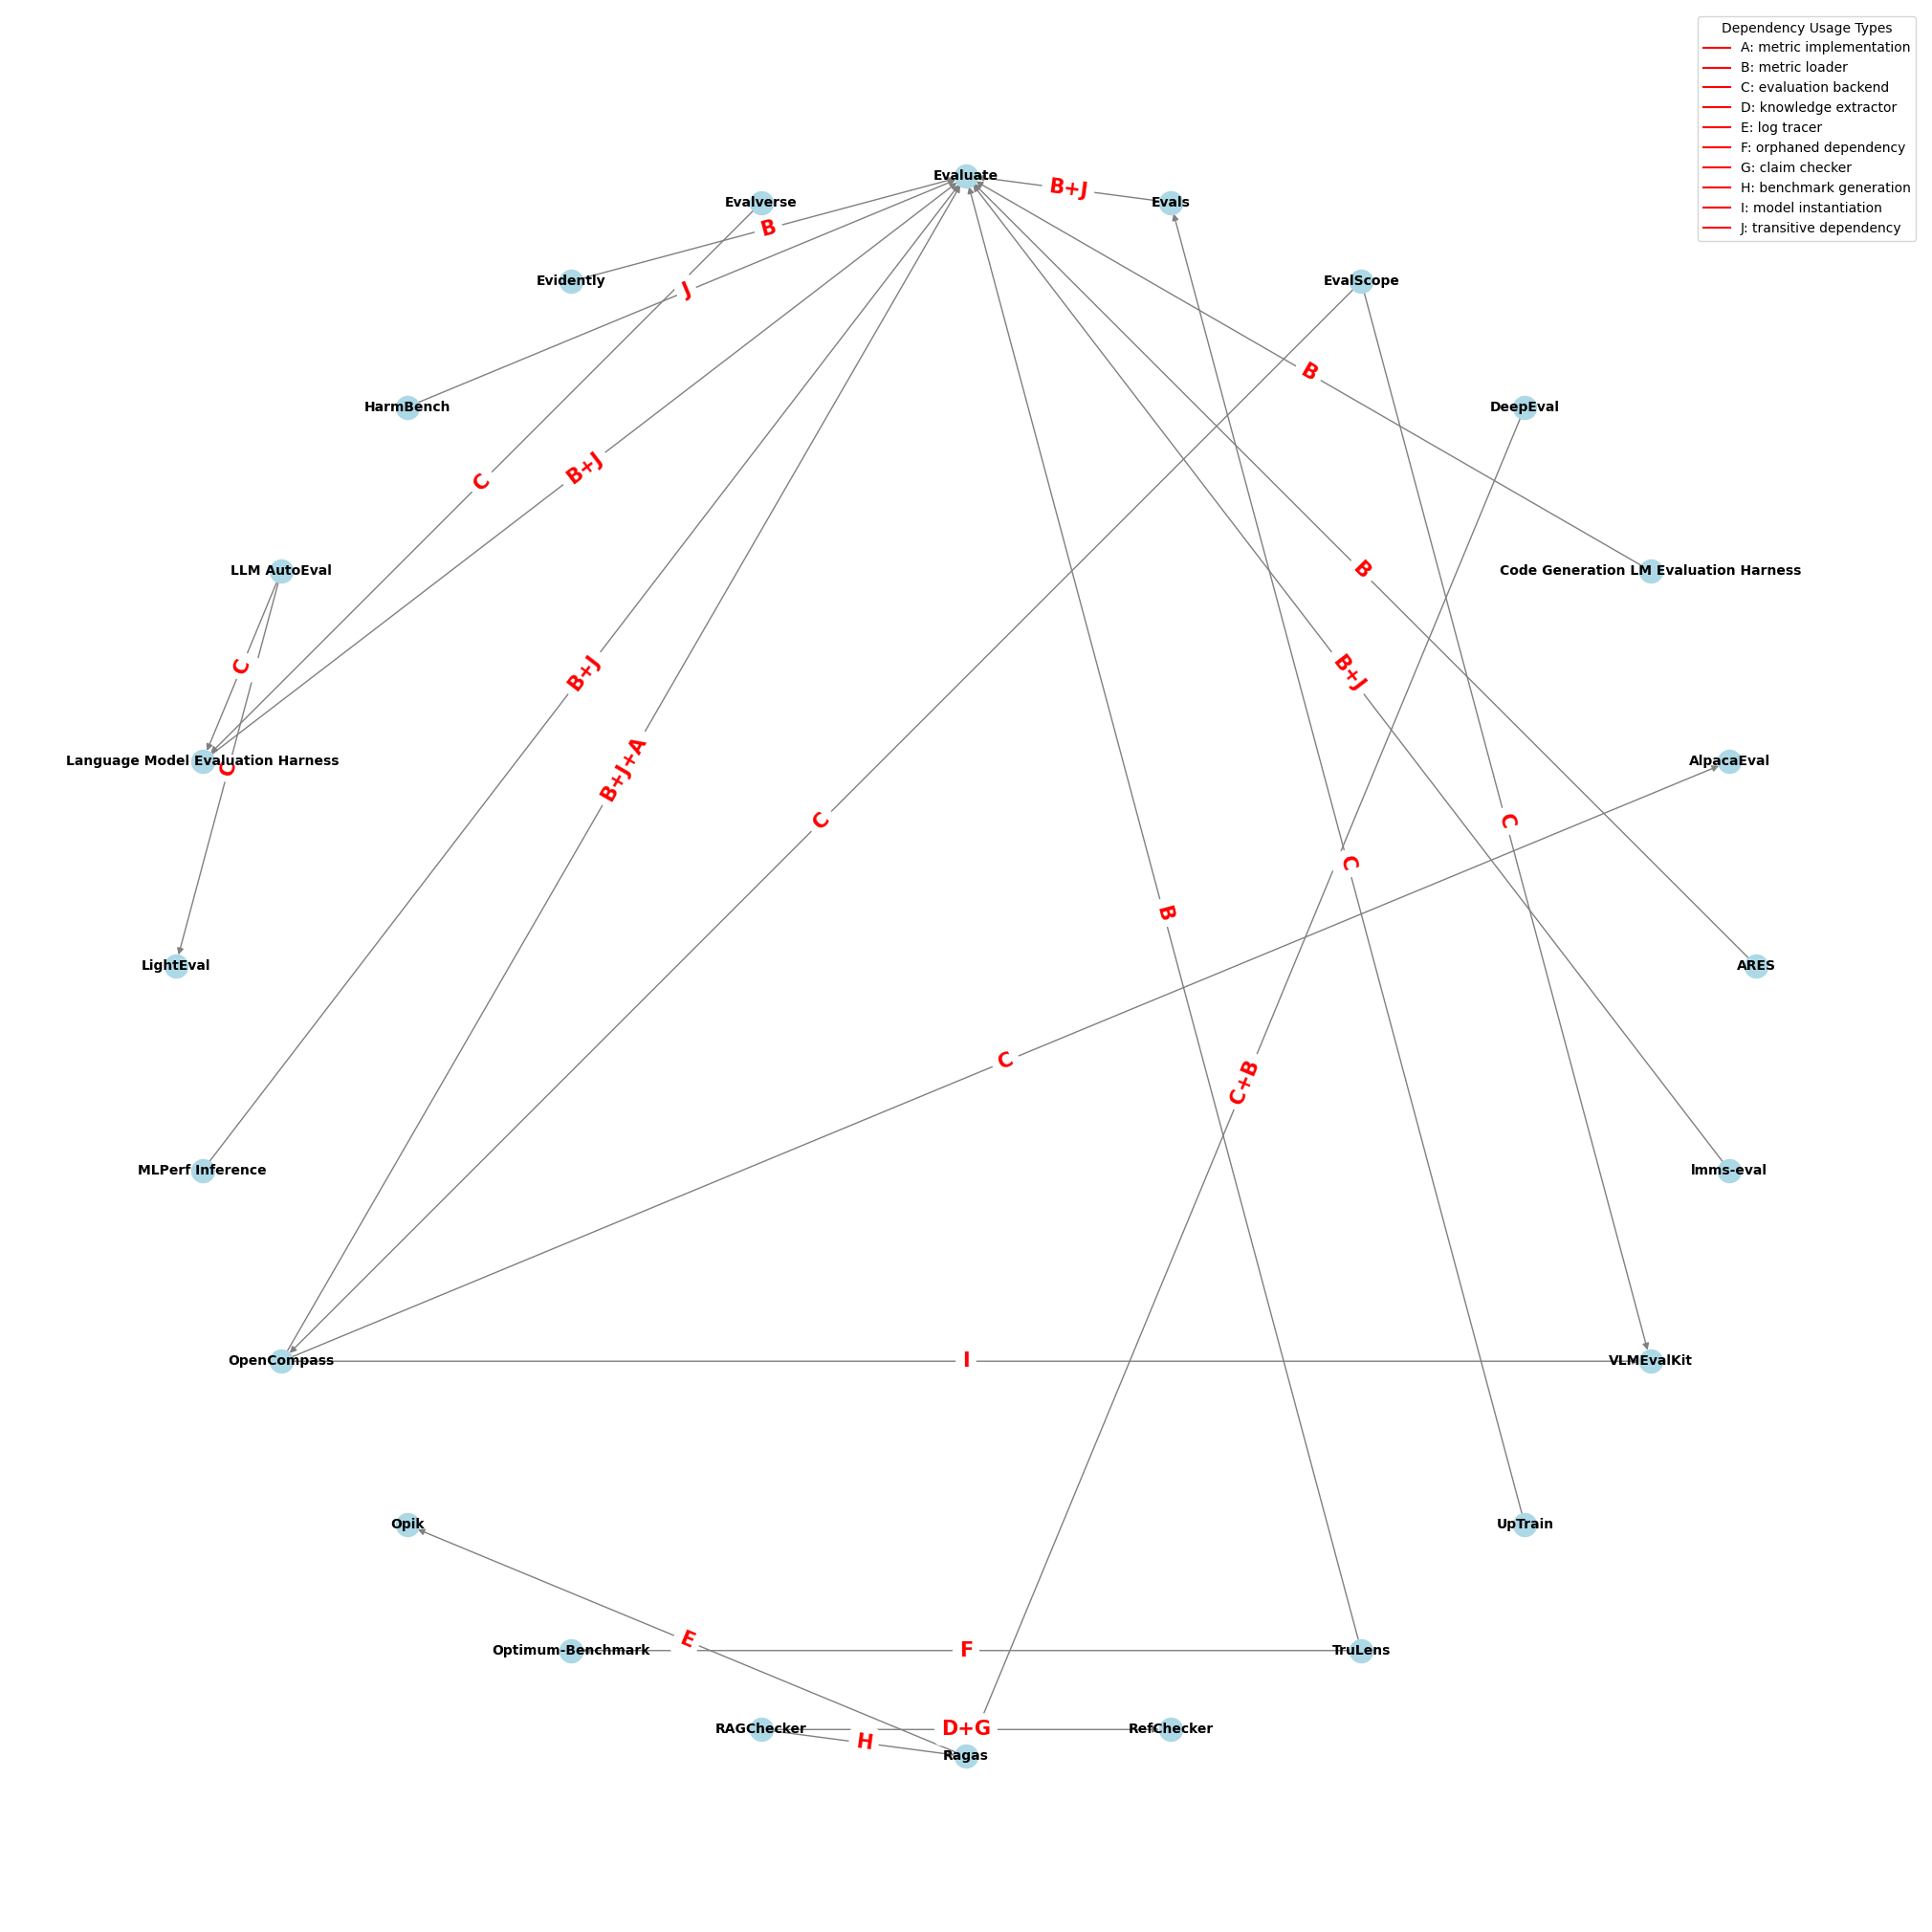

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import string
import plotly.graph_objects as go

# Create a directed graph (DiGraph to avoid multi-edges)
G = nx.DiGraph()

# Extract all unique usages from dependency_mappings_labeled
unique_usages = set()
for mapping in dependency_mappings_labeled:
    unique_usages.update(mapping["usages"])

# Automatically map unique usage types to uppercase letters
usage_to_label = {
    usage: letter for usage, letter in zip(unique_usages, string.ascii_uppercase)
}

# Add edges with combined usage annotations
edge_labels = {}

# Collect nodes and sort them alphabetically
all_nodes = set()
for mapping in dependency_mappings_labeled:
    all_nodes.add(mapping["dependent"])
    all_nodes.add(mapping["dependency"])

sorted_nodes = sorted(all_nodes)  # Sort nodes alphabetically

# Rebuild dependency_mappings_labeled in sorted order of nodes (optional)
sorted_mappings = sorted(
    dependency_mappings_labeled, key=lambda x: (x["dependent"], x["dependency"])
)

edge_count = 0
# Add sorted edges with combined usage annotations
for mapping in sorted_mappings:
    dependent = mapping["dependent"]
    dependency = mapping["dependency"]
    usages = mapping["usages"]

    # Combine all usage labels for a single edge
    usage_labels = [usage_to_label[usage] for usage in usages]
    combined_label = "+".join(usage_labels)

    # Add edge with the combined label
    G.add_edge(dependent, dependency)

    # Store the edge label for displaying
    edge_labels[(dependent, dependency)] = combined_label

    edge_count += len(usages)

print(f"Total number of edges: {edge_count}")

# Increase figure size
plt.figure(figsize=(20, 20))

# Arrange nodes in a circular layout with sorted alphabetical order
n = len(sorted_nodes)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)

# Create the position dictionary where nodes are placed in alphabetical order
pos = {
    node: (np.cos(angle), np.sin(angle)) for node, angle in zip(sorted_nodes, angles)
}

# Draw the graph with nodes and edges
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=300,
    font_size=10,
    font_weight="bold",
    edge_color="gray",
    arrows=True,
    font_color="black",
)

# Draw the edge labels (annotations) with enlarged size and red color
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, font_color="red", font_weight="bold", font_size=15
)

# Create a custom legend for the usage types
legend_labels = {label: usage for usage, label in usage_to_label.items()}
handles = [
    plt.Line2D([0], [0], color="red", label=f"{label}: {usage}")
    for label, usage in legend_labels.items()
]
plt.legend(handles=handles, title="Dependency Usage Types")

# Show the directed graph plot
plt.show()

# ---- Bar Chart with Plotly ----

# Count occurrences of each unique usage
usage_counts = {usage: 0 for usage in unique_usages}
for mapping in dependency_mappings_labeled:
    for usage in mapping["usages"]:
        usage_counts[usage] += 1

# Sort the usage counts in descending order
sorted_usage_counts = dict(
    sorted(usage_counts.items(), key=lambda item: item[1], reverse=True)
)

# Create bar chart using Plotly
fig = go.Figure(
    data=[
        go.Bar(
            name="Usage Count",
            x=list(sorted_usage_counts.keys()),
            y=list(sorted_usage_counts.values()),
            text=list(sorted_usage_counts.values()),  # Add text for each bar
            textposition="outside",  # Position text on top of the bars
        )
    ]
)

# Update layout for better visibility
fig.update_layout(
    xaxis_title="Usage Type",
    yaxis_title="Count",
    template="plotly_white",
    margin=dict(l=20, r=20, t=20, b=20),  # Tighten all margins
)

# Display the bar chart
fig.show()

In [ ]:
# df = pd.read_json("data/harnesses.json", lines=True)
# df2 = df.copy()

# implicit_dependency_mapping_labeled = []
# for index, row in df.iterrows():
#     for index2, row2 in df2.iterrows():
#         implicit_dependency_mapping = {
#         "dependent": row["tool_name"],
#         "dependency": row2["tool_name"],
#         "usages": [],
#         "references": [],
#         }
#         implicit_dependency_mapping_labeled.append(implicit_dependency_mapping)

# implicit_dependency_mapping_labeled

In [ ]:
implicit_dependency_mapping_labeled = [
    {
        "dependency": "AlpacaEval",
        "dependent": "HarmBench",
        "usages": ["benchmark recommendation"],
        "references": [
            "https://github.com/centerforaisafety/HarmBench/blob/8e1604d1171fe8a48d8febecd22f600e462bdcdd/adversarial_training/alignment-handbook/scripts/README.md?plain=1#L112"
        ],
    },
    # {
    #     "dependency": "AlpacaEval",
    #     "dependent": "OpenCompass",
    #     "usages": ["evaluation class", "evaluation dataset"],
    #     "references": ["https://github.com/open-compass/opencompass/blob/cfbd308edf2e2aa2b86e4275c7278dafaf611a44/opencompass/tasks/outer_eval/alpacaeval.py#L77", "https://github.com/open-compass/opencompass/blob/cfbd308edf2e2aa2b86e4275c7278dafaf611a44/opencompass/utils/datasets_info.py#L360"]
    # },
    {
        "dependency": "AlpacaEval",
        "dependent": "Prometheus-Eval",
        "usages": ["evaluation dataset"],
        "references": [
            "https://github.com/prometheus-eval/prometheus-eval/blob/b7a431a553b320e0a7cc49c6c5d3c54b1b840d39/eval/benchmark/data_loader.py#L21"
        ],
    },
    {
        "dependency": "AlpacaEval",
        "dependent": "RewardBench",
        "usages": ["format conversion", "evaluation dataset"],
        "references": [
            "https://github.com/allenai/reward-bench/blob/82bd441dc54190da54d230a67e4d6d7076568b1d/analysis/bon_to_alpacaeval.py#L15",
            "https://github.com/allenai/reward-bench/blob/82bd441dc54190da54d230a67e4d6d7076568b1d/rewardbench/utils.py#L407",
        ],
    },
    {
        "dependency": "ARES",
        "dependent": "RAGChecker",
        "usages": ["evaluation metric"],
        "references": [
            "https://github.com/amazon-science/RAGChecker/blob/038584e0b7e11a681da6749a0e29c0faab75e9c1/data/meta_evaluation/meta_eval.py#L25"
        ],
    },
    {
        "dependency": "ARES",
        "dependent": "Rageval",
        "usages": ["prompt reference"],
        "references": [
            "https://github.com/gomate-community/rageval/blob/c25311497aace256806fe4565858594026a2d926/benchmarks/auto/README.md?plain=1#L32"
        ],
    },
    {
        "dependency": "EvalAI",
        "dependent": "lmms-eval",
        "usages": ["output processor"],
        "references": [
            "https://github.com/EvolvingLMMs-Lab/lmms-eval/blob/a2a881c06bcfa3dd2711d1b9612c0a76de338999/lmms_eval/tasks/_task_utils/vqa_eval_metric.py#L4"
        ],
    },
    {
        "dependency": "Evals",
        "dependent": "Banana-lyzer",
        "usages": ["concept alignment"],
        "references": [
            "https://github.com/reworkd/bananalyzer/blob/ed2ba16e474ba882583bc06b27eba5997ece69d4/README.md?plain=1#L27"
        ],
    },
    {
        "dependency": "Evals",
        "dependent": "FMBench",
        "usages": ["concept alignment"],
        "references": [
            "https://github.com/aws-samples/foundation-model-benchmarking-tool/blob/3322918ace0f804e6c258f09085009fedce17c3e/src/fmbench/globals.py#L269"
        ],
    },
    {
        "dependency": "Evals",
        "dependent": "HELM",
        "usages": ["concept alignment"],
        "references": [
            "https://github.com/stanford-crfm/helm/blob/9cb6befda812332edec38cdef6b4e4fb0dc40412/src/helm/benchmark/metrics/summarization_critique_metrics.py#L20"
        ],
    },
    {
        "dependency": "Evals",
        "dependent": "Inspect",
        "usages": ["concept alignment"],
        "references": [
            "https://github.com/UKGovernmentBEIS/inspect_ai/blob/1b4a1741981c365f9903cff11fdde704a58ed9e0/evals/README.md?plain=1#L1"
        ],
    },
    {
        "dependency": "Evals",
        "dependent": "DeepEval",
        "usages": ["concept alignment"],
        "references": [
            "https://github.com/evidentlyai/evidently/blob/68f56f7f16fa085b0e1909b27ab368030a82b38f/README.md?plain=1#L190"
        ],
    },
    {
        "dependency": "Evals",
        "dependent": "Language Model Evaluation Harness",
        "usages": ["concept alignment"],
        "references": [
            "https://github.com/EleutherAI/lm-evaluation-harness/blob/fb963f0f0a5b28b69763590bb59676072cf43a01/lm_eval/tasks/leaderboard/README.md?plain=1#L14"
        ],
    },
    {
        "dependency": "Evals",
        "dependent": "LightEval",
        "usages": ["ceoncept alignment"],
        "references": [
            "https://github.com/huggingface/lighteval/blob/6b943ecb8d900c4f2333457df57f6fbbfa8cc034/community_tasks/_template.py#L74"
        ],
    },
    {
        "dependency": "Evals",
        "dependent": "LLM AutoEval",
        "usages": ["concept alignment"],
        "references": [
            "https://github.com/mlabonne/llm-autoeval/blob/eca29921dd3a2d8397289f3132ba1dce5837e9cf/runpod.sh#L188"
        ],
    },
    {
        "dependency": "Evals",
        "dependent": "lmms-eval",
        "usages": ["concept alignment"],
        "references": [
            "https://github.com/EvolvingLMMs-Lab/lmms-eval/blob/a2a881c06bcfa3dd2711d1b9612c0a76de338999/lmms_eval/loggers/evaluation_tracker.py#L434"
        ],
    },
    {
        "dependency": "Evals",
        "dependent": "OLMo-Eval",
        "usages": ["concept alignment"],
        "references": [
            "https://github.com/allenai/OLMo-Eval?tab=readme-ov-file#olmo-eval"
        ],
    },
    {
        "dependency": "Evals",
        "dependent": "PhaseLLM",
        "usages": ["concept alignment"],
        "references": [
            "https://github.com/wgryc/phasellm/blob/28847b7656e81e72856f6cc4718b612f4066523d/phasellm/logging.py#L89"
        ],
    },
    {
        "dependency": "Evals",
        "dependent": "Phoenix",
        "usages": ["concept alignment"],
        "references": [
            "https://github.com/Arize-ai/phoenix/blob/c9a9dc8d7d2953b88fe20daa26f11aa5d51de1ff/packages/phoenix-evals/src/phoenix/evals/classify.py#L127"
        ],
    },
    {
        "dependency": "Evals",
        "dependent": "TensorFlow Model Analysis",
        "usages": ["concept alignment"],
        "references": [
            "https://github.com/tensorflow/model-analysis/blob/83cd413a68e8d743aca4b1319304cc525a736e88/RELEASE.md?plain=1#L1254"
        ],
    },
    {
        "dependency": "Evals",
        "dependent": "TruLens",
        "usages": ["concept alignment"],
        "references": [
            "https://github.com/truera/trulens/blob/4ad3ba1dcf847da9cddbf3c1e690847c4fc77bd5/src/core/trulens/core/feedback/feedback.py#L348"
        ],
    },
    # {
    #     "dependency": "Evals",
    #     "dependent": "UpTrain",
    #     "usages": ["concept alignment"],
    #     "references": ["https://github.com/uptrain-ai/uptrain/blob/a31cc14eddcb6c0b0b12cbed15f086d98c441c6f/uptrain/framework/evals.py#L7"]
    # },
    {
        "dependency": "Evaluate",
        "dependent": "Code Generation LM Evaluation Harness",
        "usages": ["metric implementation", "code executor"],
        "references": [
            "https://github.com/bigcode-project/bigcode-evaluation-harness/blob/f0b81a9d079289881bd42f509811d42fe73e58cf/bigcode_eval/tasks/custom_metrics/pal_metric/pal_code_exec.py#L8",
            "https://github.com/bigcode-project/bigcode-evaluation-harness/blob/f0b81a9d079289881bd42f509811d42fe73e58cf/bigcode_eval/tasks/custom_metrics/pal_metric/python_executor.py#L2",
        ],
    },
    {
        "dependency": "Evaluate",
        "dependent": "Language Model Evaluation Harness",
        "usages": ["metric implementation"],
        "references": [
            "https://github.com/EleutherAI/lm-evaluation-harness/blob/fb963f0f0a5b28b69763590bb59676072cf43a01/lm_eval/api/metrics.py#L173"
        ],
    },
    {
        "dependency": "Evaluate",
        "dependent": "lmms-eval",
        "usages": ["metric implementation"],
        "references": [
            "https://github.com/EvolvingLMMs-Lab/lmms-eval/blob/a2a881c06bcfa3dd2711d1b9612c0a76de338999/lmms_eval/api/metrics.py#L172"
        ],
    },
    {
        "dependency": "Evaluate",
        "dependent": "PromptBench",
        "usages": ["benchmark implementation"],
        "references": [
            "https://github.com/microsoft/promptbench/blob/fcda538bd779ad11612818e0645a387a462b5c3b/promptbench/metrics/squad_v2/compute_score.py#L2"
        ],
    },
    {
        "dependency": "HarmBench",
        "dependent": "HELM",
        "usages": ["benchmark implementation"],
        "references": [
            "https://github.com/stanford-crfm/helm/blob/9cb6befda812332edec38cdef6b4e4fb0dc40412/src/helm/benchmark/scenarios/harm_bench_scenario.py#L10"
        ],
    },
    {
        "dependency": "HELM",
        "dependent": "LightEval",
        "usages": ["metric implementation"],
        "references": [
            "https://github.com/huggingface/lighteval/blob/7295c78fcb63604cc18c43dd62349a6120ac8600/README.md?plain=1#L274"
        ],
    },
    {
        "dependency": "InterCode",
        "dependent": "Inspect",
        "usages": ["benchmark implementation"],
        "references": [
            "https://github.com/UKGovernmentBEIS/inspect_ai/blob/abf15e6b2b2cce5effea7727d2853653be9e7d4f/evals/gdm_capabilities/intercode_ctf/README.md?plain=1#L3"
        ],
    },
    {
        "dependency": "Language Model Evaluation Harness",
        "dependent": "Code Generation LM Evaluation Harness",
        "usages": ["metric implementation", "task creator"],
        "references": [
            "https://github.com/bigcode-project/bigcode-evaluation-harness/blob/f0b81a9d079289881bd42f509811d42fe73e58cf/bigcode_eval/tasks/codexglue_code_to_text.py#L64",
            "https://github.com/bigcode-project/bigcode-evaluation-harness/blob/f0b81a9d079289881bd42f509811d42fe73e58cf/templates/new_task.py#L1",
        ],
    },
    {
        "dependency": "Language Model Evaluation Harness",
        "dependent": "HELM",
        "usages": ["benchmark implementation"],
        "references": [
            "https://github.com/stanford-crfm/helm/blob/9cb6befda812332edec38cdef6b4e4fb0dc40412/src/helm/benchmark/scenarios/mmlu_scenario.py#L19"
        ],
    },
    {
        "dependency": "Language Model Evaluation Harness",
        "dependent": "Inspect",
        "usages": ["benchmark implementation"],
        "references": [
            "https://github.com/UKGovernmentBEIS/inspect_ai/blob/abf15e6b2b2cce5effea7727d2853653be9e7d4f/evals/drop/drop.py#L8"
        ],
    },
    {
        "dependency": "Language Model Evaluation Harness",
        "dependent": "LightEval",
        "usages": ["output baseline"],
        "references": [
            "https://github.com/huggingface/lighteval/blob/7295c78fcb63604cc18c43dd62349a6120ac8600/src/lighteval/models/dummy_model.py#L23"
        ],
    },
    {
        "dependency": "Language Model Evaluation Harness",
        "dependent": "lmms-eval",
        "usages": ["evaluation backend", "documentation"],
        "references": [
            "https://github.com/EvolvingLMMs-Lab/lmms-eval/blob/a2a881c06bcfa3dd2711d1b9612c0a76de338999/README.md?plain=1#L43",
            "https://github.com/EvolvingLMMs-Lab/lmms-eval/blob/a2a881c06bcfa3dd2711d1b9612c0a76de338999/docs/README.md?plain=1#L5",
        ],
    },
    {
        "dependency": "Language Model Evaluation Harness",
        "dependent": "OLMo-Eval",
        "usages": ["code format"],
        "references": [
            "https://github.com/allenai/OLMo-Eval/blob/51c5ba579e75ef4ce7e9b29936eaa72c1a0e99eb/olmo_eval/tasks/olmes_v0_1/README.md?plain=1#L36"
        ],
    },
    {
        "dependency": "LightEval",
        "dependent": "Evals",
        "usages": ["evaluation dataset"],
        "references": [
            "https://github.com/openai/evals/blob/234bcde34b5951233681455faeb92baaaef97573/evals/elsuite/steganography/scripts/dataset/dataset.py#L41"
        ],
    },
    {
        "dependency": "LightEval",
        "dependent": "Language Model Evaluation Harness",
        "usages": ["evaluation dataset"],
        "references": [
            "https://github.com/EleutherAI/lm-evaluation-harness/blob/fb963f0f0a5b28b69763590bb59676072cf43a01/lm_eval/tasks/leaderboard/math/_template_yaml#L1"
        ],
    },
    {
        "dependency": "Prometheus-Eval",
        "dependent": "RewardBench",
        "usages": ["prompt template"],
        "references": [
            "https://github.com/allenai/reward-bench/blob/82bd441dc54190da54d230a67e4d6d7076568b1d/rewardbench/generative.py#L155"
        ],
    },
    {
        "dependency": "Ragas",
        "dependent": "EvalScope",
        "usages": ["harness recommendation"],
        "references": [
            "https://github.com/modelscope/evalscope/blob/789d5c15efa4cb3b2947dba4bbcf5038db7ad8c4/docs/en/blog/RAG/RAG_Evaluation.md?plain=1#L22"
        ],
    },
    {
        "dependency": "Ragas",
        "dependent": "Opik",
        "usages": ["harness integration"],
        "references": [
            "https://github.com/comet-ml/opik/blob/46012fa17a1f4ccdb7ad19a61116c9844f8c6c4e/apps/opik-documentation/documentation/docs/tracing/integrations/ragas.md?plain=1#L6"
        ],
    },
    {
        "dependency": "Ragas",
        "dependent": "Phoenix",
        "usages": ["harness integration"],
        "references": [
            "https://github.com/Arize-ai/phoenix/blob/5883c5af296bc77f5249ec955b397ef041041507/docs/integrations/ragas.md?plain=1#L5"
        ],
    },
    {
        "dependency": "Ragas",
        "dependent": "Rageval",
        "usages": ["prompt template"],
        "references": [
            "https://github.com/gomate-community/rageval/blob/c25311497aace256806fe4565858594026a2d926/rageval/utils/RAGAS_prompt.py#L4"
        ],
    },
    {
        "dependency": "RAGChecker",
        "dependent": "EvalScope",
        "usages": ["harness recommendation"],
        "references": [
            "https://github.com/modelscope/evalscope/blob/789d5c15efa4cb3b2947dba4bbcf5038db7ad8c4/docs/en/blog/RAG/RAG_Evaluation.md?plain=1#L45"
        ],
    },
    {
        "dependency": "Tonic Validate",
        "dependent": "Ragas",
        "usages": ["harness integration"],
        "references": [
            "https://github.com/explodinggradients/ragas/blob/78b54c6dca6e14dea6d7412274f6601b26a7c175/docs/howtos/integrations/tonic-validate.ipynb"
        ],
    },
    {
        "dependency": "TruLens",
        "dependent": "EvalScope",
        "usages": ["harness recommendation"],
        "references": [
            "https://github.com/modelscope/evalscope/blob/789d5c15efa4cb3b2947dba4bbcf5038db7ad8c4/docs/en/blog/RAG/RAG_Evaluation.md?plain=1#L49"
        ],
    },
    {
        "dependency": "TruLens",
        "dependent": "RAGChecker",
        "usages": ["evaluation metric"],
        "references": [
            "https://github.com/amazon-science/RAGChecker/blob/038584e0b7e11a681da6749a0e29c0faab75e9c1/data/meta_evaluation/meta_eval.py#L21"
        ],
    },
    {
        "dependency": "continuous-eval",
        "dependent": "EvalScope",
        "usages": ["harness recommendation"],
        "references": [
            "https://github.com/modelscope/evalscope/blob/789d5c15efa4cb3b2947dba4bbcf5038db7ad8c4/docs/en/blog/RAG/RAG_Evaluation.md?plain=1#L60"
        ],
    },
]


def compare_mapping_list_by_same(list1, list2):
    # Function to check if two dictionaries are the same by 'dependent' and 'dependency'
    def dicts_equal_by_keys(dict1, dict2):
        return dict1.get("dependent") == dict2.get("dependent") and dict1.get(
            "dependency"
        ) == dict2.get("dependency")

    # Find elements that are present in both list1 and list2
    same_elements = [
        d for d in list1 if any(dicts_equal_by_keys(d, d2) for d2 in list2)
    ]

    # Return the common elements
    return same_elements


compare_mapping_list_by_same(
    implicit_dependency_mapping_labeled, dependency_mappings_labeled
)

[{'dependency': 'Evaluate',
  'dependent': 'Code Generation LM Evaluation Harness',
  'usages': ['metric implementation', 'code executor'],
  'references': ['https://github.com/bigcode-project/bigcode-evaluation-harness/blob/f0b81a9d079289881bd42f509811d42fe73e58cf/bigcode_eval/tasks/custom_metrics/pal_metric/pal_code_exec.py#L8',
   'https://github.com/bigcode-project/bigcode-evaluation-harness/blob/f0b81a9d079289881bd42f509811d42fe73e58cf/bigcode_eval/tasks/custom_metrics/pal_metric/python_executor.py#L2']},
 {'dependency': 'Evaluate',
  'dependent': 'Language Model Evaluation Harness',
  'usages': ['metric implementation'],
  'references': ['https://github.com/EleutherAI/lm-evaluation-harness/blob/fb963f0f0a5b28b69763590bb59676072cf43a01/lm_eval/api/metrics.py#L173']},
 {'dependency': 'Evaluate',
  'dependent': 'lmms-eval',
  'usages': ['metric implementation'],
  'references': ['https://github.com/EvolvingLMMs-Lab/lmms-eval/blob/a2a881c06bcfa3dd2711d1b9612c0a76de338999/lmms_eval/ap

Total number of edges: 49


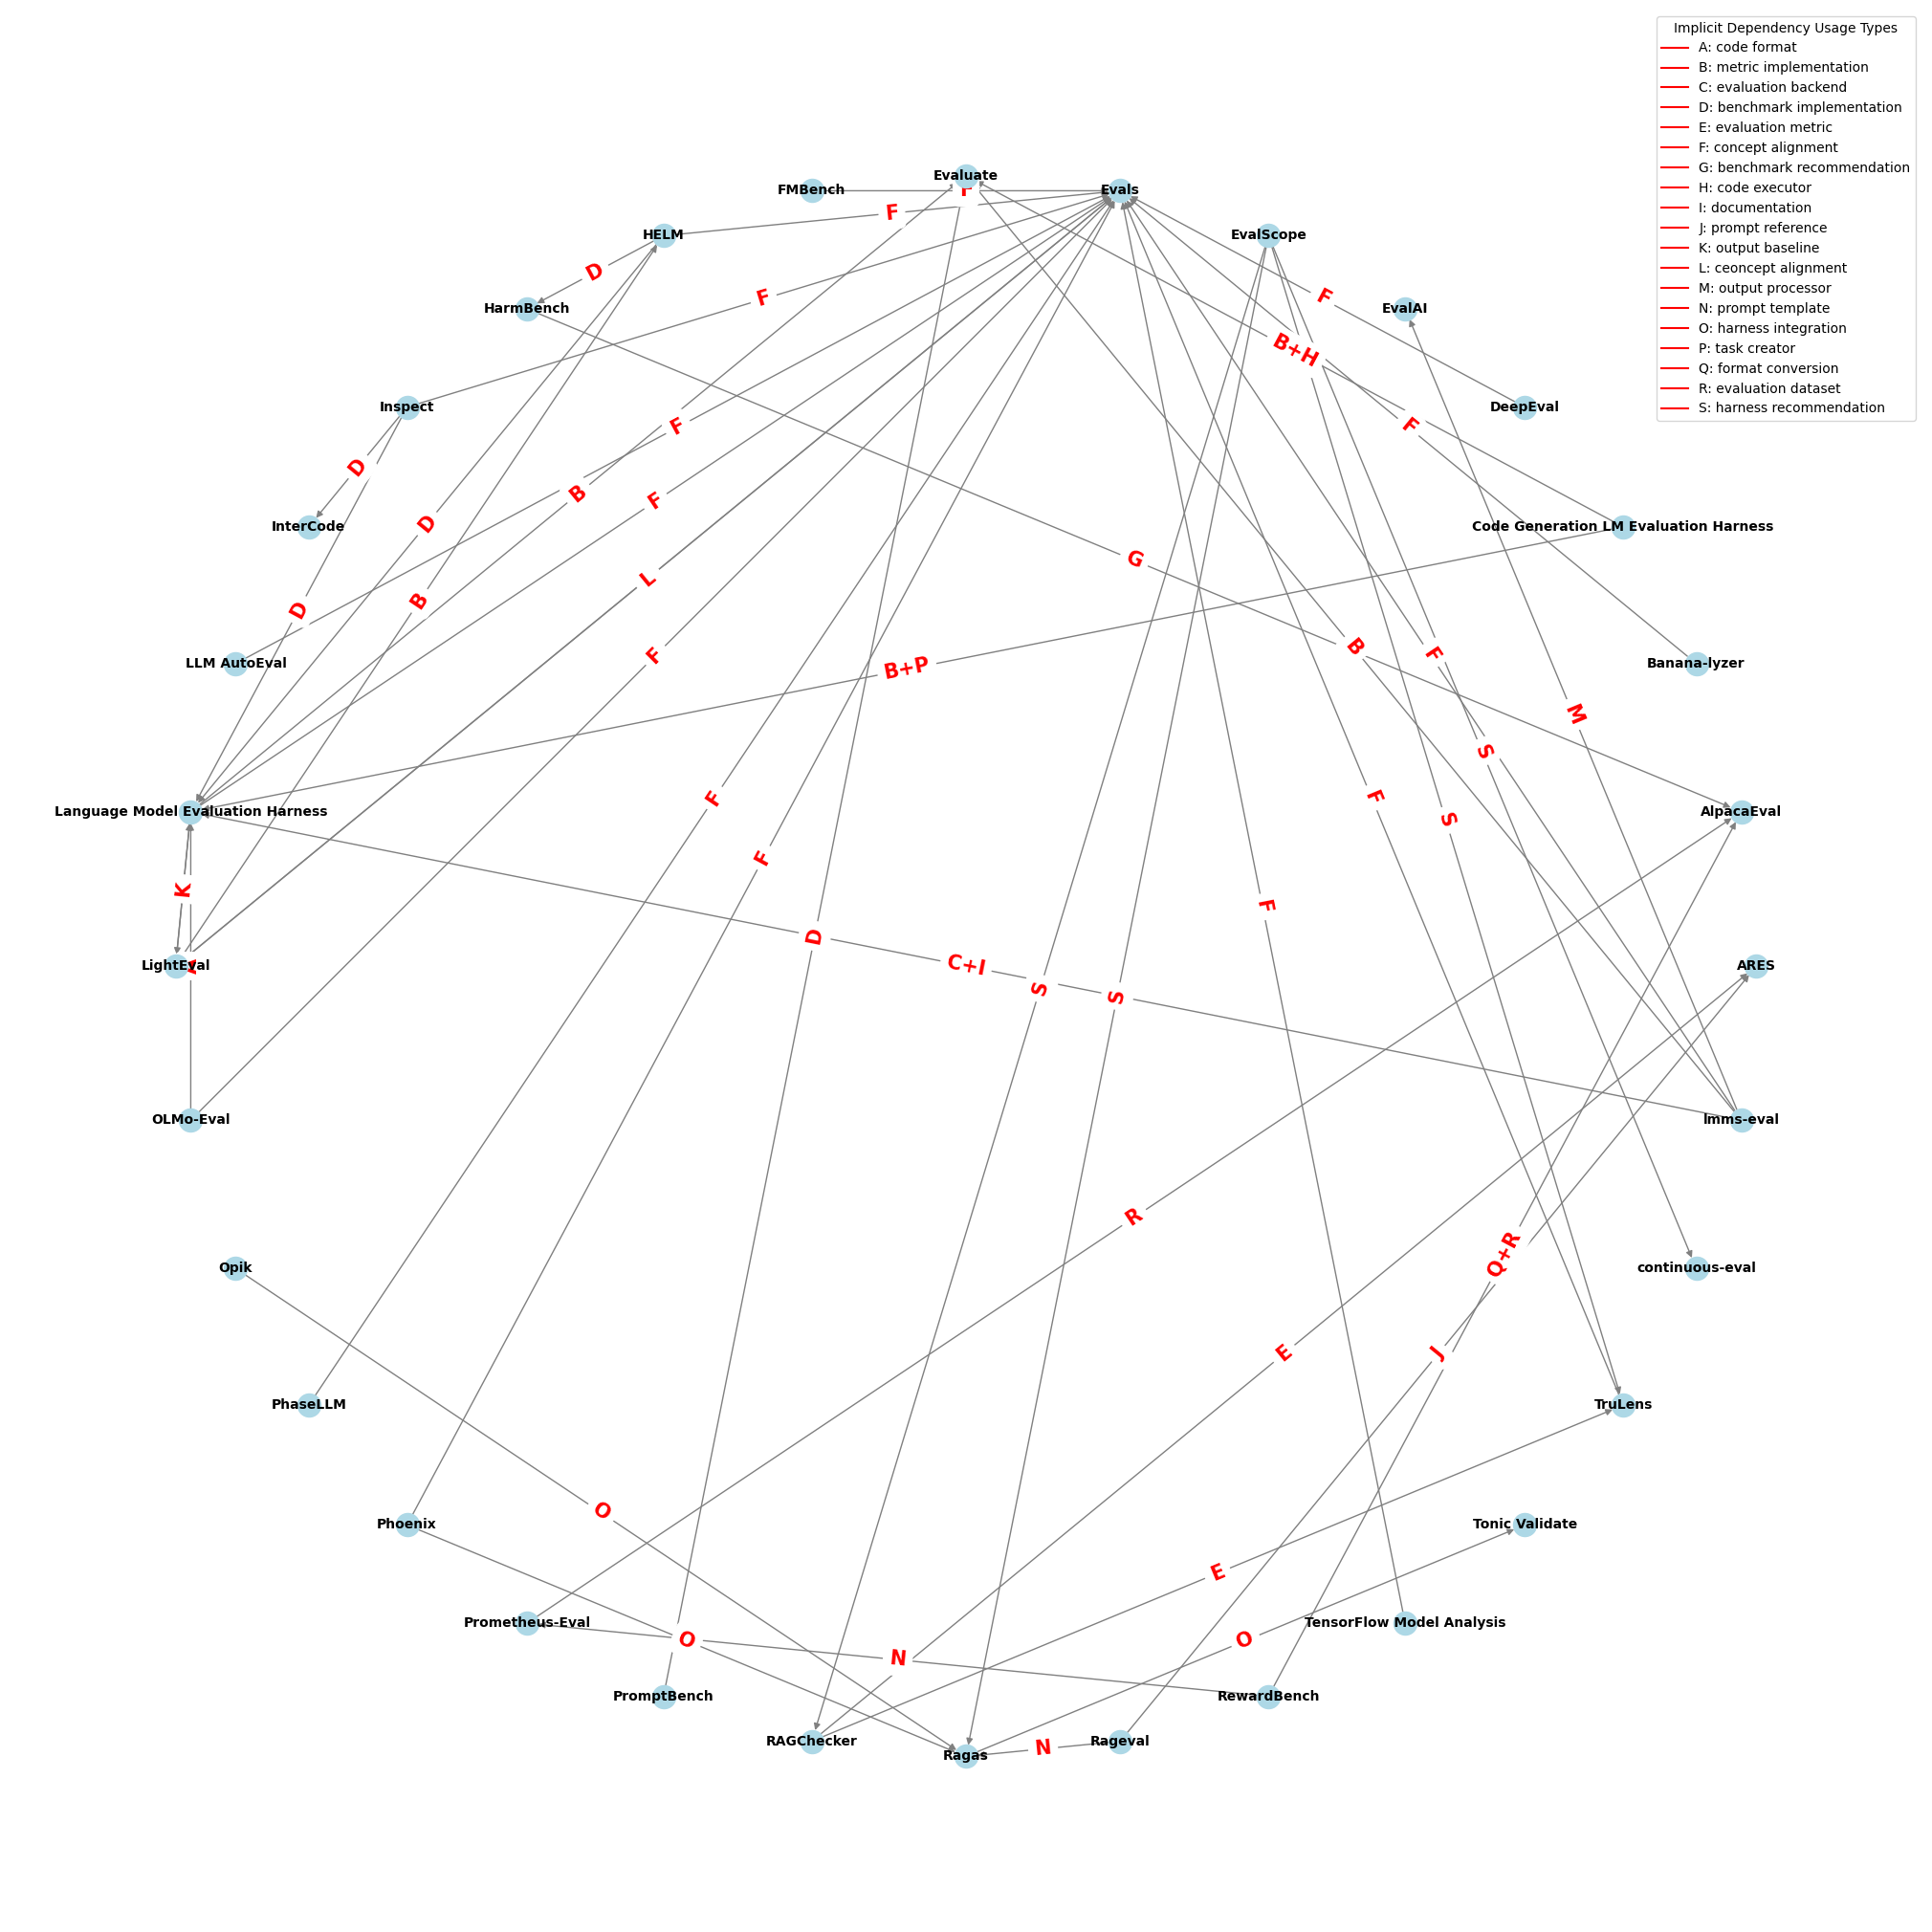

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import string
import plotly.graph_objects as go
import numpy as np

# Create a directed graph (DiGraph to avoid multi-edges)
G = nx.DiGraph()

# Extract all unique usages from dependency_mappings_labeled
unique_usages = set()
for mapping in implicit_dependency_mapping_labeled:
    unique_usages.update(mapping["usages"])

# Automatically map unique usage types to uppercase letters
usage_to_label = {
    usage: letter for usage, letter in zip(unique_usages, string.ascii_uppercase)
}

# Add edges with combined usage annotations
edge_labels = {}

# Collect nodes and sort them alphabetically
all_nodes = set()
for mapping in implicit_dependency_mapping_labeled:
    all_nodes.add(mapping["dependent"])
    all_nodes.add(mapping["dependency"])

sorted_nodes = sorted(all_nodes)  # Sort nodes alphabetically

# Rebuild dependency_mappings_labeled in sorted order of nodes (optional)
sorted_mappings = sorted(
    implicit_dependency_mapping_labeled, key=lambda x: (x["dependent"], x["dependency"])
)

edge_count = 0
# Add sorted edges with combined usage annotations
for mapping in sorted_mappings:
    dependent = mapping["dependent"]
    dependency = mapping["dependency"]
    usages = mapping["usages"]

    # Combine all usage labels for a single edge
    usage_labels = [usage_to_label[usage] for usage in usages]
    combined_label = "+".join(usage_labels)

    # Add edge with the combined label
    G.add_edge(dependent, dependency)

    # Store the edge label for displaying
    edge_labels[(dependent, dependency)] = combined_label

    edge_count += len(usages)

print(f"Total number of edges: {edge_count}")

# Increase figure size
plt.figure(figsize=(20, 20))

# Arrange nodes in a circular layout with sorted alphabetical order
n = len(sorted_nodes)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)

# Create the position dictionary where nodes are placed in alphabetical order
pos = {
    node: (np.cos(angle), np.sin(angle)) for node, angle in zip(sorted_nodes, angles)
}

# Draw the graph with nodes and edges
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=300,
    font_size=10,
    font_weight="bold",
    edge_color="gray",
    arrows=True,
    font_color="black",
)

# Draw the edge labels (annotations) with enlarged size and red color
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, font_color="red", font_weight="bold", font_size=15
)

# Create a custom legend for the usage types
legend_labels = {label: usage for usage, label in usage_to_label.items()}
handles = [
    plt.Line2D([0], [0], color="red", label=f"{label}: {usage}")
    for label, usage in legend_labels.items()
]
plt.legend(handles=handles, title="Implicit Dependency Usage Types")

# Show the directed graph plot
plt.show()

# ---- Bar Chart with Plotly ----

# Count occurrences of each unique usage
usage_counts = {usage: 0 for usage in unique_usages}
for mapping in implicit_dependency_mapping_labeled:
    for usage in mapping["usages"]:
        usage_counts[usage] += 1

# Sort the usage counts in descending order
sorted_usage_counts = dict(
    sorted(usage_counts.items(), key=lambda item: item[1], reverse=True)
)

# Create bar chart using Plotly
fig = go.Figure(
    data=[
        go.Bar(
            name="Usage Count",
            x=list(sorted_usage_counts.keys()),
            y=list(sorted_usage_counts.values()),
            text=list(sorted_usage_counts.values()),  # Add text for each bar
            textposition="outside",  # Position text automatically (inside or outside)
        )
    ]
)

# Update layout for better visibility
fig.update_layout(
    xaxis_title="Mention Type",
    yaxis_title="Count",
    template="plotly_white",
    margin=dict(l=20, r=20, t=20, b=20),  # Tighten all margins
)

# Display the bar chart
fig.show()

In [ ]:
# df = pd.read_json("data/dependents.json", lines=True)

# df_dependents = pd.read_json("data/dependents.json", lines=True)

# from github import Github
# from github import Auth

# # Load GitHub token from a JSON file
# with open(f"{path_key}/.github.json") as f:
#     github_token = json.load(f)["login_or_token"]
#     auth = Auth.Token(github_token)
#     g = Github(auth=auth)

# repo_info_list = []
# for index, row in df.iterrows():
#     for dependent in row["dependent"]:
#         link = f'https://github.com/{dependent}'
#         repo_info = df_dependents[df_dependents["link"] == link]
#         if not repo_info.empty:
#             repo_info = {
#                 "harness": row["harness"],
#                 "link": repo_info["link"].values[0],
#                 "num_stars": repo_info["num_stars"].values[0],
#                 "last_update": repo_info["last_update"].values[0],
#             }
#         else:
#             try:
#                 repo = g.get_repo(dependent)
#                 repo_info = {
#                     "harness": row["harness"],
#                     "link": repo.html_url,
#                     "num_stars": repo.stargazers_count,
#                     "last_update": repo.updated_at,
#                 }

#             except Exception as e:
#                 print(f"Error retrieving data for repository {dependent}: {e}")
#         repo_info_list.append(repo_info)

# df_repo_info = pd.DataFrame(repo_info_list)
# df_repo_info.to_json("data/dependents.json", orient="records", lines=True)

In [ ]:
# from github import Github
# from github import Auth

# # Load GitHub token from a JSON file
# with open(f"{path_key}/.github.json") as f:
#     github_token = json.load(f)["login_or_token"]
#     auth = Auth.Token(github_token)
#     g = Github(auth=auth)

# df = pd.read_json("data/dependents.json", lines=True)

# df_repo = []
# dependents = {}
# for index, row in df.iterrows():
#     print(f"Processing harness: {row['Harness']}")
#     for dependent in row["dependent"]:
#         print(f"Processing dependent: {dependent}")
#         if dependent in dependents:
#             repo_info = dependents[dependent]
#         else:
#             try:
#                 repo = g.get_repo(dependent)
#                 repo_info = {
#                     "harness": row["harness"],
#                     "link": repo.html_url,
#                     "num_stars": repo.stargazers_count,
#                     "last_update": repo.updated_at,
#                 }
#                 dependents[dependent] = repo_info
#             except Exception as e:
#                 print(f"Error retrieving data for repository {dependent}: {e}")
#         df_repo.append(repo_info)

# df_repo = pd.DataFrame(df_repo)
# df_repo.to_json("data/dependents.json", orient="records", lines=True)

In [ ]:
import webbrowser

harness_true_positive = [
    "DeepEval",
    "Evaluate",
    "MTEB",
    "Ragas",
]


def input_coding(link):
    webbrowser.open(link)
    user_input = input("Enter 'esc' to exit or provide input.")

    if user_input.lower() == "esc":
        raise KeyboardInterrupt("Execution interrupted by user.")
    elif user_input.lower() == "y":
        return True
    else:
        return False


df = pd.read_json("data/harnesses.json", lines=True)
harness_link_mapping = dict(zip(df_harnesses["link"], df_harnesses["tool_name"]))

df = pd.read_json("data/dependents.json", lines=True)
df["conclusion"] = df["harness"].apply(lambda x: x in harness_link_mapping)

# df = df[df['num_stars'] >= 1]
# df['last_update'] = pd.to_datetime(df['last_update'], unit='ms')
# df = df[df['last_update'] >= pd.Timestamp('now') - pd.DateOffset(years=1)]

for index, row in df.iterrows():
    print(harness_link_mapping[row["harness"]])
    for dependent in row["dependent"]:
        print(dependent)
        # df.at[index, "conclusion"] = input_coding(dependent)
    # df.to_json("data/dependents_filtered.json", orient="records", lines=True)

FlagEval
TensorFlow Model Analysis
https://github.com/GoogleCloudPlatform/training-data-analyst
https://github.com/GoogleCloudPlatform/mlops-with-vertex-ai
https://github.com/tensorflow/tfx-addons
https://github.com/amygdala/code-snippets
https://github.com/data-science-on-aws/data-science-on-aws
https://github.com/google/eng-edu
https://github.com/deep-diver/gpt2-ft-pipeline
https://github.com/deep-diver/semantic-segmentation-ml-pipeline
https://github.com/tensorflow/model-card-toolkit
https://github.com/googleforgames/clean-chat
https://github.com/PipelineAI/pipeline
https://github.com/Building-ML-Pipelines/building-machine-learning-pipelines
https://github.com/tensorflow/fairness-indicators
https://github.com/https-deeplearning-ai/machine-learning-engineering-for-production-public
https://github.com/GoogleCloudPlatform/mlops-on-gcp
https://github.com/kubeflow-kale/kale
https://github.com/intel/intel-xai-tools
https://github.com/ciandt-d1/chicago-taxi-forecast
https://github.com/kube

In [ ]:
import plotly.express as px

df = pd.read_json("data/dependents_filtering.json", lines=True)

# Calculate the proportion of occurrence for each category
category_counts = df["Catorgory"].value_counts(normalize=True) * 100

# Create a bar chart using Plotly
fig = px.bar(
    category_counts,
    x=category_counts.index,
    y=category_counts.values,
    labels={"x": "Category", "y": "Proportion (%)"},
    title="Distribution of Categories Based on Proportion of Occurrence",
)

# Display the chart
fig.show()

In [ ]:
# from selenium.webdriver.common.by import By
# from seleniumbase import Driver
# import time


# def scrape_discussion(driver, repo):
#     base_url = f'https://github.com/{repo}/discussions/categories/q-a?page='
#     posts_url_lst = set()
#     index = 0

#     while True:
#         index += 1
#         page_url = base_url + str(index)
#         posts_url = get_url(driver, page_url)

#         if not posts_url:
#             break

#         posts_url_lst = posts_url_lst.union(posts_url)

#     posts = pd.DataFrame()
#     for url in posts_url_lst:
#         post = get_data(driver, url)
#         if not post:
#             continue
#         posts = pd.concat([posts, pd.DataFrame([post])], ignore_index=True)
#     return posts


# def get_url(driver, url):
#     driver.get(url)

#     posts_url = set()
#     post_list = driver.find_elements(
#         By.XPATH, '//div[@class="lh-condensed pl-2 pr-3 flex-1"]/h3/a')

#     for post in post_list:
#         posts_url.add(post.get_attribute('href'))

#     return posts_url


# def get_data(driver, url):
#     driver.get(url)

#     post = {}

#     try:
#         # question_title
#         title = driver.find_element(
#             By.XPATH, '//span[@class="js-issue-title markdown-title"]').text
#         # print("Title:", title)
#     except:
#         print(url)
#         return post

#     # question_tag_count
#     tag_count = len(driver.find_elements(By.XPATH, '//div[@class="discussion-sidebar-item js-discussion-sidebar-item"]/div[2]/a'))
#     # print("tag_count:", tag_count)

#     # Question_created_time
#     date = driver.find_element(
#         By.XPATH, '//relative-time[@class="no-wrap"]').get_attribute("datetime")
#     # print("date:", date)

#     # Question_score_count
#     upvote_count = driver.find_element(
#         By.XPATH, '//div[@class="text-center discussion-vote-form position-relative"]//button').get_attribute('aria-label')
#     upvote_count = convert2num(upvote_count)
#     # print("Question_score_count:", upvote_count)

#     # question_body
#     body = driver.find_element(
#         By.XPATH, '//td[@class="d-block color-fg-default comment-body markdown-body js-comment-body"]').get_attribute("innerText").strip()
#     # print("body:", body)

#     # question_answer_count
#     answer_count = driver.find_element(
#         By.XPATH, '//h2[@id="discussion-comment-count"]/span[2]').get_attribute("innerText").strip()
#     answer_count = convert2num(answer_count)
#     # print("answer_count:", len(answers_lst))

#     post["Question_title"] = title
#     post["Question_tag_count"] = tag_count
#     post["Question_link"] = url
#     post["Question_created_time"] = date
#     post["Question_answer_count"] = answer_count
#     post["Question_score_count"] = upvote_count
#     post["Question_body"] = body

#     info = driver.find_element(By.XPATH, '//div[@class="d-flex flex-wrap flex-items-center mb-3 mt-2"]')
#     accepted = info.find_element(By.XPATH, './/span').get_attribute('title')

#     if accepted == 'Answered':
#         answerer = info.find_element(By.XPATH, './/a[@class="Link--secondary text-bold"]').text
#         poster = info.find_element(By.XPATH, './/a[@class="Link--secondary text-bold d-inline-block"]').get_attribute('innerText').strip()
#         post['Question_self_closed'] = poster == answerer
#         answer = driver.find_element(By.XPATH, '//section[@class="width-full" and @aria-label="Marked as Answer"]')
#         post['Question_closed_time'] = answer.find_element(By.XPATH, './/relative-time').get_attribute('datetime')
#         comments = answer.find_elements(By.XPATH, './/td[@class="d-block color-fg-default comment-body markdown-body js-comment-body px-3 pt-0 pb-2"]/p')
#         post['Answer_comment_count'] = len(comments)
#         post['Answer_comment_body'] = ' '.join([comment.get_attribute('innerText').strip() for comment in comments])
#         try:
#             Answer_score_count = answer.find_element(By.XPATH, './/div[@class="text-center discussion-vote-form position-relative"]//button').get_attribute('aria-label')
#             post['Answer_score_count'] = convert2num(Answer_score_count)
#             try:
#                 post['Answer_body'] = answer.find_element(By.XPATH, './/td[@class="d-block color-fg-default comment-body markdown-body js-comment-body"]').get_attribute('innerText').strip()
#             except:
#                 post['Answer_body'] = answer.find_element(By.XPATH, './/td[@class="d-block color-fg-default comment-body markdown-body js-comment-body email-format"]/div').get_attribute('innerText').strip()
#         except:
#             post['Answer_body'] = answer.find_element(By.XPATH, './/td[@class="d-block color-fg-default comment-body markdown-body js-comment-body px-3 pt-0 pb-2"]').get_attribute('innerText').strip()

#     return post


# def convert2num(num):
#     try:
#         return int(num)
#     except:
#         try:
#             return int(num.strip().split()[0])
#         except:
#             try:
#                 return int(num.strip().split()[-1])
#             except:
#                 return 0

# driver = Driver(uc=True)
# driver.implicitly_wait(5)
# driver.get('https://github.com')
# time.sleep(30)
# discussions = pd.DataFrame()
# for repo in repo_list:
#     repo_discussions = scrape_discussion(driver, repo)
#     repo_discussions['Repository'] = repo
#     discussions = pd.concat([discussions, repo_discussions], ignore_index=True)
# discussions.to_json(f'{path_data}/discussions.json', orient='records', lines=True)
# driver.quit()

In [ ]:
from bertopic import BERTopic

os.environ["TOKENIZERS_PARALLELISM"] = "true"

# Load issues from a JSON file
issues_file = "data/issues.json"
df = pd.read_json(issues_file, lines=True)
issues = df["preprocessed_message"].tolist()

# Create a BERTopic model
topic_model = BERTopic(min_topic_size=120)

# Fit the model to the documents
topics, probabilities = topic_model.fit_transform(issues)

# Reassign outliers (-1) to the topic with the highest probability
for i, topic in enumerate(topics):
    if topic == -1:
        # Find the topic with the highest probability
        max_prob_topic = np.argmax(probabilities[i])
        topics[i] = max_prob_topic

# Get the topic information
topic_info = topic_model.get_topic_info()

# Visualize the topics
# topic_model.visualize_topics().show()
topic_model.visualize_barchart(top_n_topics=len(np.unique(topics))).show()
topic_model.visualize_hierarchy().show()

# Save the topic information to a CSV file
topic_info.to_csv("topic_info.csv", encoding="utf-8", index=False)
print(topic_info)

/Users/jimmy/Documents/GitHub/Evalware-Survey/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning:

This process (pid=2398) is multi-threaded, use of fork() may lead to deadlocks in the child.

/Users/jimmy/Documents/GitHub/Evalware-Survey/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning:

This process (pid=2398) is multi-threaded, use of fork() may lead to deadlocks in the child.

/Users/jimmy/Documents/GitHub/Evalware-Survey/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning:

This process (pid=2398) is multi-threaded, use of fork() may lead to deadlocks in the child.

/Users/jimmy/Documents/GitHub/Evalware-Survey/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning:

This process (pid=2398) is multi-threaded, use of fork() may lead to deadlocks in the child.



    Topic  Count                                           Name  \
0      -1  11487              -1_add_update_frontend_evaluation   
1       0   1437                             0_mmmlu_sh_mmmu_pl   
2       1   1014                     1_eval_evals_evaluator_add   
3       2    833                      2_tests_test_testset_unit   
4       3    656             3_models_model_huggingface_hugging   
5       4    603                   4_dataset_datasets_data_mbpp   
6       5    512           5_documentation_docs_update_document   
7       6    459               6_metrics_metric_distance_custom   
8       7    456  7_benchmark_benchmarks_inference_benchmarking   
9       8    453      8_language_function_translation_languages   
10      9    401              9_score_answer_scores_correctness   
11     10    382                    10_file_path_files_download   
12     11    367           11_version_update_versioning_updates   
13     12    327    12_classification_visualization_plot_repor

In [5]:
import pandas as pd

df = pd.read_csv("data/evaluation_harness_metadata.csv", encoding="utf-8")
df['supported evaluation methodology'] = df['supported evaluation methodology'].apply(lambda x: x.split(","))
# sum the number of occurrences of each evaluation methodology
evaluation_methodology_counts = df['supported evaluation methodology'].explode().value_counts()
print(f"Total number of evaluation methodologies: {evaluation_methodology_counts.sum()}")
evaluation_methodology_counts

Total number of evaluation methodologies: 96


supported evaluation methodology
compare model output with reference using predefined metrics     34
grade model output using predefined metrics                      20
grade model output using LLM annotator                           10
compare model output with reference using LLM annotator           8
 grade model output using LLM annotator                           6
test model output with unit tests                                 6
 compare model output with reference using predefined metrics     4
examine model output using human annotator                        2
 compare model output with reference using LLM annotator          2
test model output using predefined metrics                        2
highly customizable                                               1
 grade model output using predefined metrics                      1
Name: count, dtype: int64

In [ ]:
repo_urls = """https://github.com/tatsu-lab/alpaca_eval
https://github.com/erikbern/ann-benchmarks
https://github.com/stanford-futuredata/ARES
https://github.com/Marker-Inc-Korea/AutoRAG
https://github.com/beir-cellar/beir
https://github.com/RobustNLP/CipherChat
https://github.com/bigcode-project/bigcode-evaluation-harness
https://github.com/Unbabel/COMET
https://github.com/confident-ai/deepeval
https://github.com/facebookresearch/DomainBed
https://github.com/Cloud-CV/EvalAI
https://github.com/evalplus/evalplus
https://github.com/openai/evals
https://github.com/modelscope/evalscope
https://github.com/huggingface/evaluate
https://github.com/evidentlyai/evidently
https://github.com/OpenLMLab/GAOKAO-Bench
https://github.com/Giskard-AI/giskard
https://github.com/stanford-crfm/helm
https://github.com/openai/human-eval
https://github.com/UKGovernmentBEIS/inspect_ai
https://github.com/plurai-ai/intellagent
https://github.com/jitsi/jiwer
https://github.com/EleutherAI/lm-evaluation-harness
https://github.com/huggingface/lighteval
https://github.com/ray-project/llmperf
https://github.com/EvolvingLMMs-Lab/lmms-eval
https://github.com/google-deepmind/meltingpot
https://github.com/Farama-Foundation/Metaworld
https://github.com/mir-evaluation/mir_eval
https://github.com/mlcommons/inference
https://github.com/snap-stanford/ogb
https://github.com/dezoito/ollama-grid-search
https://github.com/open-compass/OpenCompass
https://github.com/comet-ml/opik
https://github.com/HumanCompatibleAI/overcooked_ai
https://github.com/prometheus-eval/prometheus-eval
https://github.com/microsoft/promptbench
https://github.com/pykeen/pykeen
https://github.com/understandable-machine-intelligence-lab/Quantus
https://github.com/explodinggradients/ragas
https://github.com/amazon-science/RAGChecker
https://github.com/AmenRa/ranx
https://github.com/allenai/reward-bench
https://github.com/stepjam/RLBench
https://github.com/simpler-env/SimplerEnv
https://github.com/openai/simple-evals
https://github.com/Picovoice/speech-to-text-benchmark
https://github.com/tensorflow/model-analysis
https://github.com/pytorch/benchmark
https://github.com/truera/trulens
https://github.com/HowieHwong/TrustLLM
https://github.com/Vchitect/VBench
https://github.com/open-compass/VLMEvalKit
https://github.com/Cloud-CV/evalai-cli"""

import os
import subprocess
import shutil
import time
import platform

# Define path for repositories
path_repo = "data/repos"

# Make sure the base directory exists
os.makedirs(path_repo, exist_ok=True)


def get_latest_commit_hash(repo_path):
    """
    Get the latest commit hash from a git repository.
    """
    try:
        result = subprocess.run(
            ["git", "rev-parse", "HEAD"],
            cwd=repo_path,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            check=True,
        )
        return result.stdout.strip()
    except Exception as e:
        print(f"Error getting commit hash for {repo_path}: {str(e)}")
        return None


def get_commit_info(repo_path):
    """
    Get commit hash, date, and message for the latest commit.

    Args:
        repo_path (str): Path to the git repository

    Returns:
        dict: Dictionary containing 'hash', 'date', and 'message' keys,
              or None if an error occurs
    """
    try:
        # Get commit hash
        hash_result = subprocess.run(
            ["git", "rev-parse", "HEAD"],
            cwd=repo_path,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            check=True,
        )
        commit_hash = hash_result.stdout.strip()
        return commit_hash

    except subprocess.CalledProcessError as e:
        print(f"Git command failed for {repo_path}: {e.stderr.strip()}")
        return None
    except FileNotFoundError:
        print(f"Git not found or repository path invalid: {repo_path}")
        return None
    except Exception as e:
        print(f"Error getting commit info for {repo_path}: {str(e)}")
        return None


def safe_remove_directory(path):
    """
    Safely remove a directory, handling Windows permission errors
    by attempting multiple times with delays.
    """
    if not os.path.exists(path):
        return

    # First, try to make files writable in case they're read-only
    try:
        if platform.system() == "Windows":
            subprocess.run(
                ["attrib", "-R", path + "\\*.*", "/S"], shell=True, check=False
            )
    except:
        pass  # Ignore errors from this step

    max_attempts = 3
    for attempt in range(max_attempts):
        try:
            print(f"Cleanup attempt {attempt+1} for {path}")
            shutil.rmtree(path, ignore_errors=True)
            if not os.path.exists(path):
                print(f"Successfully removed {path}")
                return

            print(
                f"Directory still exists after removal attempt {attempt+1}. Waiting..."
            )
            time.sleep(3)
        except Exception as e:
            print(f"Error during cleanup attempt {attempt+1}: {str(e)}")
            if attempt < max_attempts - 1:
                time.sleep(3)

    print(
        f"Warning: Failed to remove {path} after {max_attempts} attempts. Continuing..."
    )


def clone_problematic_quantus(repo_path, url):
    """
    Special handling for the Quantus repository which has problematic files
    using a sparse checkout approach.
    """
    # Initialize git repo
    os.makedirs(repo_path, exist_ok=True)

    try:
        # Initialize empty git repo
        subprocess.run(["git", "init"], cwd=repo_path, check=True)

        # Add remote
        subprocess.run(
            ["git", "remote", "add", "origin", url], cwd=repo_path, check=True
        )

        # Enable sparse checkout
        subprocess.run(
            ["git", "config", "core.sparseCheckout", "true"], cwd=repo_path, check=True
        )

        # Create sparse-checkout file to exclude the problematic directory
        sparse_checkout_path = os.path.join(
            repo_path, ".git", "info", "sparse-checkout"
        )
        with open(sparse_checkout_path, "w") as f:
            f.write("/*\n")
            f.write("!tests/assets/Icon*\n")  # Exclude the problematic Icon file

        # Fetch and checkout
        subprocess.run(["git", "fetch", "origin", "main"], cwd=repo_path, check=True)
        subprocess.run(["git", "checkout", "main"], cwd=repo_path, check=True)

        return True
    except Exception as e:
        print(f"Failed to clone {url} with sparse checkout: {str(e)}")
        return False


# Keep track of successful and failed repositories
successful_repos = []
failed_repos = []
repo_commit_info = {}  # Store repo info with commit hashes

# Try to set Git config to allow special characters
try:
    subprocess.run(["git", "config", "--global", "core.protectNTFS", "false"])
except:
    print("Warning: Could not set git config core.protectNTFS")

# Process each repository
for url in repo_urls.split("\n"):
    if not url:  # Skip empty lines
        continue

    print(f"\nCloning: {url}")

    # Create a clean repo name from the URL
    repo_name = ("__").join(url.split("/")[3:])
    if repo_name.endswith(".git"):
        repo_name = repo_name[:-4]  # Remove .git extension if present

    repo_path = os.path.join(path_repo, repo_name)

    # Check if repo already exists and get its commit hash
    if os.path.exists(repo_path):
        print(f"Repository already exists at {repo_path}")
        repo_commit_info[url.split("/")[-1]] = get_commit_info(repo_path)
        print("Skipping clone...")
        continue

    # Handle the problematic Quantus repository with a special approach
    if "understandable-machine-intelligence-lab/Quantus" in url:
        print(f"Using special handling for known problematic repository: {url}")
        if clone_problematic_quantus(repo_path, url):
            successful_repos.append(url)
            repo_commit_info[url.split("/")[-1]] = get_commit_info(repo_path)
        else:
            failed_repos.append((url, "Failed with special handling"))
            safe_remove_directory(repo_path)
        continue

    try:
        result = subprocess.run(
            ["git", "clone", url, repo_path],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
        )

        if result.returncode != 0:
            print(f"Error cloning {url}: {result.stderr}")
            failed_repos.append((url, result.stderr))
            time.sleep(2)
            safe_remove_directory(repo_path)
            continue

        successful_repos.append(url)

    except Exception as e:
        print(f"Unexpected error cloning {url}: {str(e)}")
        failed_repos.append((url, str(e)))
        time.sleep(2)
        safe_remove_directory(repo_path)

In [ ]:
import pandas as pd
import subprocess
import ast
import re
import os
from pathlib import Path

# Base directory containing all repositories
path_repo = Path("data/repos")

# These prefixes are used to identify internal or private files that should be excluded from analysis
internal_usage_prefix = [
    "_",
    ".",
]

# Keywords to exclude during analysis
test_keywords = [
    "test"
]
usecase_keywords = [
    "debug",
    "demo",
    "example",
    "experiment",
    "notebook",
    "result",
    "tutorial",
]
deprecated_keywords = [
    "deprecated",
    "deprecation",
    "legacy",
    "obsolete",
    "old",
    "retired",
]
usecase_test_keywords = test_keywords + usecase_keywords
test_deprecated_keywords = test_keywords + deprecated_keywords
excluded_keywords = test_keywords + usecase_keywords + deprecated_keywords

# Prepare the --exclude argument for deadcode
exclude_arg = ",".join([f"*{dir}*" for dir in usecase_test_keywords])

# Dictionary to store all results
evaluation_results = {}


def preprocess_path(path):
    path_parts = path.split(os.sep)
    org_name, repo_name = path_parts[2].split("__")[0], path_parts[2].split("__")[1]
    file_path = os.path.join(*path_parts[3:]).replace(os.sep, "/")
    file_path_url = f"https://github.com/{org_name}/{repo_name}/blob/{repo_commit_info[repo_name]}/{file_path}"
    return file_path_url


def find_cli_commands(repo_path):
    """Find all CLI calls in the repository."""
    results = []

    for root, dirs, files in os.walk(repo_path):
        for file in files:
            filepath = os.path.join(root, file)
            
            has_internal_usage = False
            for prefix in internal_usage_prefix:
                for subdir in filepath.split(os.sep):
                    if subdir.startswith(prefix):
                        has_internal_usage = True
                        break
                if has_internal_usage:
                    break

            has_forbidden_usage = False
            for keyword in excluded_keywords:
                if keyword in filepath.lower():
                    has_forbidden_usage = True
                    break

            if has_internal_usage or has_forbidden_usage or not file.endswith(".py"):
                continue
        
            try:
                with open(filepath, "r", encoding="utf-8") as f:
                    content = f.read()
                    file_path_url = preprocess_path(filepath)
                    for line_num, line in enumerate(content.split("\n"), 1):
                        # Look for the main entry point
                        matches = re.findall(
                            r"^\s*(?!#+)if\s+__name__\s*==\s*(['\"])(__main__)\1\s*:",
                            line,
                            re.MULTILINE,
                        )
                        if matches:
                            cli_dict = {
                                "type": "cli",
                                "line of code": f"{file_path_url}#L{line_num}",
                                "content": content.strip(),
                            }
                            results.append(cli_dict)

            except Exception as e:
                print(f"Error processing {filepath}: {e}")
                continue

    return results


def find_click_commands(repo_path):
    """Find all click command/option/argument decorators in the repository."""
    results = []

    for root, dirs, files in os.walk(repo_path):
        for file in files:
            filepath = os.path.join(root, file)
            
            has_internal_usage = False
            for prefix in internal_usage_prefix:
                for subdir in filepath.split(os.sep):
                    if subdir.startswith(prefix):
                        has_internal_usage = True
                        break
                if has_internal_usage:
                    break

            has_forbidden_usage = False
            for keyword in excluded_keywords:
                if keyword in filepath.lower():
                    has_forbidden_usage = True
                    break

            if has_internal_usage or has_forbidden_usage or not file.endswith(".py"):
                continue

            try:
                with open(filepath, "r", encoding="utf-8") as f:
                    content = f.read()

                if "import click" in content or "from click import " in content:
                    file_path_url = preprocess_path(filepath)
                    for line_num, line in enumerate(content.split("\n"), 1):
                        if ".add_command(" in line:
                            # Look for the command in this line first
                            matches = re.findall(
                                r"^\s*([_a-zA-Z]*)\.add_command\(([-_a-zA-Z]+)\)",
                                line,
                                re.MULTILINE,
                            )
                            if matches:
                                function_name = matches[0][1]

                                has_test_deprecated_usage = False
                                for keyword in test_deprecated_keywords:
                                    if keyword in function_name.lower():
                                        has_test_deprecated_usage = True
                                        break
            
                                has_internal_usage = False
                                for prefix in internal_usage_prefix:
                                    if function_name.startswith(prefix):
                                        has_internal_usage = True
                                        break

                                if has_test_deprecated_usage or has_internal_usage:
                                    continue

                                repo_function = (
                                    "__".join(str(repo_path).split("/")[-2:])
                                    + "/"
                                    + function_name
                                )
                                click_dict = {
                                    "type": "click",
                                    "line of code": f"{file_path_url}#L{line_num}",
                                    "function": repo_function,
                                    "content": content.strip(),
                                }
                                results.append(click_dict)

            except Exception as e:
                print(f"Error processing {filepath}: {e}")
                continue

    return results


def find_fire_commands(repo_path):
    """Find all Python-Fire CLI usages in the repository."""
    results = []

    for root, dirs, files in os.walk(repo_path):
        for file in files:
            filepath = os.path.join(root, file)
            
            has_internal_usage = False
            for prefix in internal_usage_prefix:
                for subdir in filepath.split(os.sep):
                    if subdir.startswith(prefix):
                        has_internal_usage = True
                        break
                if has_internal_usage:
                    break

            has_forbidden_usage = False
            for keyword in excluded_keywords:
                if keyword in filepath.lower():
                    has_forbidden_usage = True
                    break

            if has_internal_usage or has_forbidden_usage or not file.endswith(".py"):
                continue

            try:
                with open(filepath, "r", encoding="utf-8") as f:
                    content = f.read()

                if "import fire" in content or "from fire import " in content:
                    file_path_url = preprocess_path(filepath)
                    for line_num, line in enumerate(content.split("\n"), 1):
                        matches = re.findall(
                            r"^\s*(?!#+)(fire\.)?Fire\(([_a-zA-Z]+?)\)",
                            line,
                            re.MULTILINE,
                        )
                        if matches:
                            function_name = matches[0][1]

                            has_test_deprecated_usage = False
                            for keyword in test_deprecated_keywords:
                                if keyword in function_name.lower():
                                    has_test_deprecated_usage = True
                                    break
            
                            has_internal_usage = False
                            for prefix in internal_usage_prefix:
                                if function_name.startswith(prefix):
                                    has_internal_usage = True
                                    break

                            if has_test_deprecated_usage or has_internal_usage:
                                continue

                            repo_function = (
                                "__".join(str(repo_path).split("/")[-2:])
                                + "/"
                                + function_name
                            )
                            api_dict = {
                                "type": "fire",
                                "line of code": f"{file_path_url}#L{line_num}",
                                "function": repo_function,
                                "content": content.strip(),
                            }
                            results.append(api_dict)
            except Exception as e:
                print(f"Error processing {filepath}: {e}")
                continue

    return results


def retrieve_function(loc, function_name):
    parts = loc.split("#L")[0].split("/")
    repo_name = "__".join(parts[3:5])
    local_path = str(path_repo) + "/" + repo_name + "/" + "/".join(parts[7:])
    repo_function = repo_name + "/" + function_name

    with open(local_path, "r", encoding="utf-8") as file:
        content = file.read()

    # Extract the specific line number if needed
    # Parse the content into an AST
    tree = ast.parse(content)

    # Find the function by name
    for node in ast.walk(tree):
        if (
            isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef))
            and node.name == function_name
        ):
            # Get the line numbers for the function
            start_line = node.lineno - 1  # Convert to 0-based indexing
            end_line = (
                node.end_lineno if hasattr(node, "end_lineno") else start_line + 1
            )

            # Extract the function code
            lines = content.split("\n")
            function_content = "\n".join(lines[start_line:end_line])
            break

    return repo_function, function_content.strip()


df = []
path_repo = Path("data/repos")

for repo_path in path_repo.iterdir():
    if ".json" in str(repo_path):
        continue  # Skip JSON files

    # Run deadcode analysis
    result = subprocess.run(
        ["deadcode", str(repo_path), "--exclude", exclude_arg],
        capture_output=True,
        text=True,
        check=True,
    )

    repo_dict = []
    for line in result.stdout.splitlines():
        if " Function " in line or " Method " in line:
        
            has_internal_usage = False
            for prefix in internal_usage_prefix:
                for subdir in line.split(os.sep):
                    if subdir.startswith(prefix):
                        has_internal_usage = True
                        break
                if has_internal_usage:
                    break

            has_forbidden_usage = False
            for keyword in excluded_keywords:
                if keyword in line.lower():
                    has_forbidden_usage = True
                    break

            if not has_internal_usage and not has_forbidden_usage:
                line = line.replace("\u001b[0m", "").replace("\u001b[1m", "")
                loc = preprocess_path(line.split(": ")[0])
                loc = re.sub(r"\.py:(\d+):(\d+)", r".py#L\1", loc)      
        
                function_name = line.split("`")[1]
                has_test_deprecated_usage = False
                for keyword in test_deprecated_keywords:
                    if keyword in function_name.lower():
                        has_test_deprecated_usage = True
                        break
        
                has_internal_usage = False
                for prefix in internal_usage_prefix:
                    if function_name.startswith(prefix):
                        has_internal_usage = True
                        break

                if has_test_deprecated_usage or has_internal_usage:
                    continue

                repo_function, content = retrieve_function(loc, function_name)
                api_dict = {
                    "type": "api",
                    "line of code": loc.split(": ")[0],
                    "function": repo_function,
                    "content": content,
                }
                repo_dict.append(api_dict)

    repo_dict.extend(find_cli_commands(repo_path))
    repo_dict.extend(find_click_commands(repo_path))

    # Removing the "fire" type from the dataset as it represents CLI calls identical to __main__ calls, making them redundant.
    # repo_dict.extend(find_fire_commands(repo_path))

    if not repo_dict:
        print(f"No unused code found in {repo_path.name}")
        continue

    df.extend(repo_dict)

df = pd.DataFrame(df)
df.to_json("data/unused_python_functions.jsonl", orient="records", lines=True)

In [ ]:
import pandas as pd
import subprocess
import ast
import re
import os
from pathlib import Path

# Base directory containing all repositories
path_repo = Path("data/repos")

# These prefixes are used to identify internal or private files that should be excluded from analysis
internal_usage_prefix = [
    "_",
    ".",
]

# Keywords to exclude during analysis
test_keywords = [
    "test"
]
usecase_keywords = [
    "debug",
    "demo",
    "example",
    "experiment",
    "notebook",
    "result",
    "tutorial",
]
deprecated_keywords = [
    "deprecated",
    "deprecation",
    "legacy",
    "obsolete",
    "old",
    "retired",
]
usecase_test_keywords = test_keywords + usecase_keywords
test_deprecated_keywords = test_keywords + deprecated_keywords
excluded_keywords = test_keywords + usecase_keywords + deprecated_keywords

# Prepare the --exclude argument for deadcode
exclude_arg = ",".join([f"*{dir}*" for dir in usecase_test_keywords])

# Dictionary to store all results
evaluation_results = {}


def preprocess_path(path):
    path_parts = path.split(os.sep)
    org_name, repo_name = path_parts[2].split("__")[0], path_parts[2].split("__")[1]
    file_path = os.path.join(*path_parts[3:]).replace(os.sep, "/")
    file_path_url = f"https://github.com/{org_name}/{repo_name}/blob/{repo_commit_info[repo_name]}/{file_path}"
    return file_path_url


def find_cli_commands(repo_path):
    """Find all CLI calls in the repository."""
    results = []

    for root, dirs, files in os.walk(repo_path):
        for file in files:
            filepath = os.path.join(root, file)
            
            has_internal_usage = False
            for prefix in internal_usage_prefix:
                for subdir in filepath.split(os.sep):
                    if subdir.startswith(prefix):
                        has_internal_usage = True
                        break
                if has_internal_usage:
                    break

            has_forbidden_usage = False
            for keyword in excluded_keywords:
                if keyword in filepath.lower():
                    has_forbidden_usage = True
                    break

            if has_internal_usage or has_forbidden_usage or not file.endswith(".py"):
                continue
        
            try:
                with open(filepath, "r", encoding="utf-8") as f:
                    content = f.read()
                    file_path_url = preprocess_path(filepath)
                    for line_num, line in enumerate(content.split("\n"), 1):
                        # Look for the main entry point
                        matches = re.findall(
                            r"^\s*(?!#+)if\s+__name__\s*==\s*(['\"])(__main__)\1\s*:",
                            line,
                            re.MULTILINE,
                        )
                        if matches:
                            cli_dict = {
                                "type": "cli",
                                "line of code": f"{file_path_url}#L{line_num}",
                                "content": content.strip(),
                            }
                            results.append(cli_dict)

            except Exception as e:
                print(f"Error processing {filepath}: {e}")
                continue

    return results


def find_click_commands(repo_path):
    """Find all click command/option/argument decorators in the repository."""
    results = []

    for root, dirs, files in os.walk(repo_path):
        for file in files:
            filepath = os.path.join(root, file)
            
            has_internal_usage = False
            for prefix in internal_usage_prefix:
                for subdir in filepath.split(os.sep):
                    if subdir.startswith(prefix):
                        has_internal_usage = True
                        break
                if has_internal_usage:
                    break

            has_forbidden_usage = False
            for keyword in excluded_keywords:
                if keyword in filepath.lower():
                    has_forbidden_usage = True
                    break

            if has_internal_usage or has_forbidden_usage or not file.endswith(".py"):
                continue

            try:
                with open(filepath, "r", encoding="utf-8") as f:
                    content = f.read()

                if "import click" in content or "from click import " in content:
                    file_path_url = preprocess_path(filepath)
                    for line_num, line in enumerate(content.split("\n"), 1):
                        if ".add_command(" in line:
                            # Look for the command in this line first
                            matches = re.findall(
                                r"^\s*([_a-zA-Z]*)\.add_command\(([-_a-zA-Z]+)\)",
                                line,
                                re.MULTILINE,
                            )
                            if matches:
                                function_name = matches[0][1]

                                has_test_deprecated_usage = False
                                for keyword in test_deprecated_keywords:
                                    if keyword in function_name.lower():
                                        has_test_deprecated_usage = True
                                        break
            
                                has_internal_usage = False
                                for prefix in internal_usage_prefix:
                                    if function_name.startswith(prefix):
                                        has_internal_usage = True
                                        break

                                if has_test_deprecated_usage or has_internal_usage:
                                    continue

                                repo_function = (
                                    "__".join(str(repo_path).split("/")[-2:])
                                    + "/"
                                    + function_name
                                )
                                click_dict = {
                                    "type": "click",
                                    "line of code": f"{file_path_url}#L{line_num}",
                                    "function": repo_function,
                                    "content": content.strip(),
                                }
                                results.append(click_dict)

            except Exception as e:
                print(f"Error processing {filepath}: {e}")
                continue

    return results


def find_fire_commands(repo_path):
    """Find all Python-Fire CLI usages in the repository."""
    results = []

    for root, dirs, files in os.walk(repo_path):
        for file in files:
            filepath = os.path.join(root, file)
            
            has_internal_usage = False
            for prefix in internal_usage_prefix:
                for subdir in filepath.split(os.sep):
                    if subdir.startswith(prefix):
                        has_internal_usage = True
                        break
                if has_internal_usage:
                    break

            has_forbidden_usage = False
            for keyword in excluded_keywords:
                if keyword in filepath.lower():
                    has_forbidden_usage = True
                    break

            if has_internal_usage or has_forbidden_usage or not file.endswith(".py"):
                continue

            try:
                with open(filepath, "r", encoding="utf-8") as f:
                    content = f.read()

                if "import fire" in content or "from fire import " in content:
                    file_path_url = preprocess_path(filepath)
                    for line_num, line in enumerate(content.split("\n"), 1):
                        matches = re.findall(
                            r"^\s*(?!#+)(fire\.)?Fire\(([_a-zA-Z]+?)\)",
                            line,
                            re.MULTILINE,
                        )
                        if matches:
                            function_name = matches[0][1]

                            has_test_deprecated_usage = False
                            for keyword in test_deprecated_keywords:
                                if keyword in function_name.lower():
                                    has_test_deprecated_usage = True
                                    break
            
                            has_internal_usage = False
                            for prefix in internal_usage_prefix:
                                if function_name.startswith(prefix):
                                    has_internal_usage = True
                                    break

                            if has_test_deprecated_usage or has_internal_usage:
                                continue

                            repo_function = (
                                "__".join(str(repo_path).split("/")[-2:])
                                + "/"
                                + function_name
                            )
                            api_dict = {
                                "type": "fire",
                                "line of code": f"{file_path_url}#L{line_num}",
                                "function": repo_function,
                                "content": content.strip(),
                            }
                            results.append(api_dict)
            except Exception as e:
                print(f"Error processing {filepath}: {e}")
                continue

    return results


def retrieve_function(loc, function_name):
    parts = loc.split("#L")[0].split("/")
    repo_name = "__".join(parts[3:5])
    local_path = str(path_repo) + "/" + repo_name + "/" + "/".join(parts[7:])
    repo_function = repo_name + "/" + function_name

    with open(local_path, "r", encoding="utf-8") as file:
        content = file.read()

    # Extract the specific line number if needed
    # Parse the content into an AST
    tree = ast.parse(content)

    # Find the function by name
    for node in ast.walk(tree):
        if (
            isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef))
            and node.name == function_name
        ):
            # Get the line numbers for the function
            start_line = node.lineno - 1  # Convert to 0-based indexing
            end_line = (
                node.end_lineno if hasattr(node, "end_lineno") else start_line + 1
            )

            # Extract the function code
            lines = content.split("\n")
            function_content = "\n".join(lines[start_line:end_line])
            break

    return repo_function, function_content.strip()


df = []
path_repo = Path("data/repos")

for repo_path in path_repo.iterdir():
    if ".json" in str(repo_path):
        continue  # Skip JSON files

    result = subprocess.run(
        ["vulture", str(repo_path), "--exclude", exclude_arg, "--min-confidence", "60"],
        capture_output=True,
        text=True
    )
    '''data\repos\allenai__reward-bench\analysis\bon_to_alpacaeval.py:78: unused function 'split_dict_lists' (60% confidence)'''
    repo_dict = []
    # unique_code_lines = set()
    for line in result.stdout.splitlines():
        if " function " in line or " method " in line:
            
            has_internal_usage = False
            for prefix in internal_usage_prefix:
                for subdir in line.split(os.sep):
                    if subdir.startswith(prefix):
                        has_internal_usage = True
                        break
                if has_internal_usage:
                    break

            has_forbidden_usage = False
            for keyword in excluded_keywords:
                if keyword in line.lower():
                    has_forbidden_usage = True
                    break
                
            if not has_internal_usage and not has_forbidden_usage:
                loc = preprocess_path(line.split(": ")[0])
                loc = re.sub(r"\.py:(\d+)", r".py#L\1", loc)
          
                function_name = line.split("'")[1]
                has_test_deprecated_usage = False
                for keyword in test_deprecated_keywords:
                    if keyword in function_name.lower():
                        has_test_deprecated_usage = True
                        break
            
                has_internal_usage = False
                for prefix in internal_usage_prefix:
                    if function_name.startswith(prefix):
                        has_internal_usage = True
                        break

                if has_test_deprecated_usage or has_internal_usage:
                    continue

                repo_function, content = retrieve_function(loc, function_name)
                api_dict = {
                    "type": "api",
                    "line of code": loc.split(": ")[0],
                    "function": repo_function,
                    "content": content,
                }
                repo_dict.append(api_dict)

    # Store unused function/method lines
    repo_dict.extend(find_cli_commands(repo_path))
    repo_dict.extend(find_click_commands(repo_path))
    
    # Removing the "fire" type from the dataset as it represents CLI calls identical to __main__ calls, making them redundant.
    # repo_dict.extend(find_fire_commands(repo_path))

    if not repo_dict:
        print(f"No unused code found in {repo_path.name}")
        continue

    df.extend(repo_dict)

# Write all results to a single JSON file
df = pd.DataFrame(df)
df.to_json("data/unused_python_functions.jsonl", orient="records", lines=True)

<unknown>:202: SyntaxWarning: invalid escape sequence '\c'
<unknown>:204: SyntaxWarning: invalid escape sequence '\l'
<unknown>:211: SyntaxWarning: invalid escape sequence '\#'
<unknown>:216: SyntaxWarning: invalid escape sequence '\m'
<unknown>:246: SyntaxWarning: invalid escape sequence '\e'
<unknown>:202: SyntaxWarning: invalid escape sequence '\c'
<unknown>:204: SyntaxWarning: invalid escape sequence '\l'
<unknown>:211: SyntaxWarning: invalid escape sequence '\#'
<unknown>:216: SyntaxWarning: invalid escape sequence '\m'
<unknown>:246: SyntaxWarning: invalid escape sequence '\e'


No unused code found in dezoito__ollama-grid-search


<unknown>:70: SyntaxWarning: invalid escape sequence '\s'
<unknown>:70: SyntaxWarning: invalid escape sequence '\s'
<unknown>:70: SyntaxWarning: invalid escape sequence '\s'
<unknown>:70: SyntaxWarning: invalid escape sequence '\s'
<unknown>:70: SyntaxWarning: invalid escape sequence '\s'
<unknown>:114: SyntaxWarning: invalid escape sequence '\$'
<unknown>:130: SyntaxWarning: invalid escape sequence '\d'
<unknown>:253: SyntaxWarning: invalid escape sequence '\%'
<unknown>:114: SyntaxWarning: invalid escape sequence '\$'
<unknown>:130: SyntaxWarning: invalid escape sequence '\d'
<unknown>:253: SyntaxWarning: invalid escape sequence '\%'
<unknown>:45: SyntaxWarning: invalid escape sequence '\s'
<unknown>:45: SyntaxWarning: invalid escape sequence '\s'
<unknown>:45: SyntaxWarning: invalid escape sequence '\s'
<unknown>:22: SyntaxWarning: invalid escape sequence '\['
<unknown>:23: SyntaxWarning: invalid escape sequence '\['
<unknown>:22: SyntaxWarning: invalid escape sequence '\['
<unknown

In [15]:
import pandas as pd
import plotly.express as px

df = pd.read_json("data/unused_python_functions.jsonl", lines=True)
df["filepath"] = df["line of code"].apply(lambda x: x.split("#L")[0])
print(f"Total number of unused functions/scripts: {len(df)}")
print(
    f"Total number of files with at least one unused function: {df['filepath'].nunique()}"
)

# Extract the file name for each line of code and count how many lines per file
file_counts = df.groupby("filepath").size().reset_index(name="lines_per_file")

# Create distribution data: count how many files have each number of lines
distribution = file_counts["lines_per_file"].value_counts().reset_index()
distribution.columns = ["lines_of_code", "number_of_files"]
distribution = distribution.sort_values("lines_of_code")

# Plotting the distribution of files by number of lines of code
fig = px.bar(
    distribution,
    x="lines_of_code",
    y="number_of_files",
    labels={
        "lines_of_code": "Unused Functions/Scripts per File",
        "number_of_files": "Number of Files",
    },
    log_y=True,
)
fig.update_layout(
    margin=dict(l=20, r=20, t=40, b=20),
    xaxis=dict(title_font_size=20),
    yaxis=dict(title_font_size=20),
)
fig.show()

Total number of unused functions/scripts: 5176
Total number of files with at least one unused function: 2346


In [ ]:
import pandas as pd

# Sample 358 files for representative file-level analysis
# Sample size calculation URL: https://www.calculator.net/sample-size-calculator.html?type=1&cl=95&ci=5&pp=50&ps=5176&x=Calculate
df = pd.read_json("data/unused_python_functions.jsonl", lines=True)
df["filepath"] = df["line of code"].apply(lambda x: x.split("#L")[0])
df.drop_duplicates(subset=["filepath"], inplace=True)
df_sampled = df.sample(n=358, random_state=42).reset_index(drop=True)
df_sampled.sort_values(by="line of code", inplace=True)
df_sampled.drop(
    columns=["filepath", "content"], inplace=True
)  # Remove filepath and content columns as they are not needed for crowdsourced labeling
df_sampled.to_csv(
    "data/unused_python_function_sample.csv", encoding="utf-8", index=False
)

In [ ]:
# import pandas as pd

# df = pd.read_csv(
#     r"C:\Users\zhimi\Downloads\Evaluation Harnesses - Labels.csv", encoding="utf-8"
# )
# loc_label_mapping = dict(zip(df["line of code"], df["label"]))

# df = pd.read_json("data/unused_python_functions.jsonl", lines=True)
# df["label"] = df["line of code"].map(loc_label_mapping)

# df.drop(columns=["content"], inplace=True)  # Remove content column as it's not needed anymore
# df.to_csv("data/unused_python_functions_labels.csv", encoding="utf-8", index=False)

In [ ]:
# import pandas as pd

# df = pd.read_csv(r"C:\Users\zhimi\Downloads\Evaluation Harnesses - Labels.csv")
# loc_label_mapping = dict(zip(df["line of code"], df["label"]))

# df_old_sample = pd.read_csv(r"C:\Users\zhimi\Downloads\Evaluation Harnesses - Samples.csv")
# for id, row in df_old_sample.iterrows():
#     if row["line of code"] in loc_label_mapping:
#         df_old_sample.at[id, "label"] = loc_label_mapping[row["line of code"]]
#     else:
#         df_old_sample.drop(index=id, inplace=True)

# df = df[~df["line of code"].isin(df_old_sample["line of code"])]

# number = 358 - len(df_old_sample)
# df_new_sample = df.sample(n=number, random_state=42)
# df_sample = pd.concat([df_old_sample, df_new_sample], ignore_index=True)
# df_sample.to_csv(
#     r"data\unused_python_function_sample_labels.csv", index=False
# )

# df_sample = df_sample[["type", "line of code", "function"]]
# df_sample.to_csv(
#     r"data\unused_python_function_sample.csv", index=False
# )

In [13]:
import pandas as pd
import plotly.express as px

# Load the dataset
df = pd.read_csv(r"data/unused_python_functions_labels.csv")
print(f"Total number of deprecated functions: {len(df[df['label'] == 'deprecated function'])} ({len(df[df['label'] == 'deprecated function'])/len(df)*100:.2f}%)")
print(f"Total number of passthrough functions: {len(df[df['label'] == 'passthrough function'])} ({len(df[df['label'] == 'passthrough function'])/len(df)*100:.2f}%)")
print(f"Total number of unimplemented functions: {len(df[df['label'] == 'unimplemented function'])} ({len(df[df['label'] == 'unimplemented function'])/len(df)*100:.2f}%)")
# Filter out deprecated, passthrough or unimplemented functions
df = df[~df["label"].isin(["deprecated function", "passthrough function", "unimplemented function"])]
print(f"Total number of unused functions after filtering: {len(df)}")
# First, let's see what columns we have after groupby
occurrence_frequency = df.groupby("label")["type"].count().reset_index()
occurrence_frequency.rename(columns={"type": "occurrence_count"}, inplace=True)
occurrence_frequency.sort_values(by="occurrence_count", ascending=False, inplace=True)
occurrence_frequency.head(10)

Total number of deprecated functions: 13 (0.25%)
Total number of passthrough functions: 8 (0.15%)
Total number of unimplemented functions: 350 (6.76%)
Total number of unused functions after filtering: 4805


,label,occurrence_count
1600,generate run specification,63
1325,generate action,50
1568,generate question prompt,45
142,calculate accuracy,40
2406,return items,39
825,create run specification,39
1552,generate prompt,31
1661,generate translation prompt,30
1777,install requirements,30
637,convert image to rgb,24


In [14]:
import pandas as pd
import plotly.express as px

# Load the dataset
df = pd.read_csv(r"data/unused_python_functions_labels.csv")
df = df[~df["label"].isin(["passthrough function", "unimplemented function"])]

# First, let's see what columns we have after groupby
occurrence_frequency = df.groupby("label")["type"].count().reset_index()

# Import Counter
from collections import Counter

frequency_counts = Counter(occurrence_frequency["type"])

# Convert Counter to DataFrame for plotting
frequency_df = pd.DataFrame.from_dict(
    frequency_counts, orient="index", columns=["count"]
).reset_index()
frequency_df.columns = ["label_occurrence_frequency", "count"]

# Create bar chart for occurrence frequency
fig = px.bar(
    frequency_df,
    x="label_occurrence_frequency",
    y="count",
    title="Distribution of Label Occurrence Frequency",
    text="count",
    log_x=True,
    log_y=True,
)

fig.update_traces(textposition="outside")
fig.update_layout(xaxis_tickangle=-45, margin=dict(l=20, r=20, t=40, b=60))

fig.show()

In [24]:
import pandas as pd
import spacy
import re

from collections import defaultdict
from typing import List, Dict, Tuple, Set, Optional
from spacy.language import Language
from spacy.tokens import Doc, Span
from spacy.util import filter_spans

@Language.component("merge_hyphenated")
def merge_hyphenated(doc):
    spans_to_merge = []
    
    # Find all hyphenated patterns
    i = 0
    while i < len(doc) - 2:
        if (doc[i+1].text == "-" and 
            doc[i].is_alpha and 
            doc[i+2].is_alpha):
            # Create a span for the three tokens (word-word)
            span = Span(doc, i, i+3)
            spans_to_merge.append(span)
            i += 3  # Skip past this group to avoid overlaps
        else:
            i += 1
    
    # Filter overlapping spans and merge
    spans_to_merge = filter_spans(spans_to_merge)
    
    with doc.retokenize() as retokenizer:
        for span in spans_to_merge:
            retokenizer.merge(span)
    
    return doc

class VerbNounMapper:
    def __init__(self):
        # Load spaCy model
        try:
            self.nlp = spacy.load("en_core_web_sm")
            self.nlp.add_pipe("merge_hyphenated", before="tagger")
        except OSError:
            print("spaCy English model not found.")
            print("Please install it using:")
            print("pip install spacy")
            print("python -m spacy download en_core_web_sm")
            raise

    def split_compound_labels(self, label: str) -> List[str]:
        """
        Split compound labels into individual labels based on connectives.
        Handles:
        - "verb1 and/or verb2 noun" => ["verb1 noun", "verb2 noun"]
        - "verb noun1 and/or noun2" => ["verb noun1", "verb noun2"]
        - "verb1 noun1 and/or verb2 noun2" => ["verb1 noun1", "verb2 noun2"]
        """
        doc = self.nlp(label)
        
        for id, token in enumerate(doc):
            if token.pos_ == "CCONJ":
                if id == 1:
                    label1 = doc[id - 1].text + " " + " ".join(t.text for t in doc[id + 2:])
                    label2 = doc[id + 1].text + " " + " ".join(t.text for t in doc[id + 2:])
                    # print("scenario 1")
                    return [label1, label2]
                elif doc[id - 1].pos_ == "NOUN" and doc[id + 1].pos_ != "VERB":
                    label1 = " ".join(t.text for t in doc[:id])
                    label2 = doc[0].text + " " + " ".join(t.text for t in doc[id + 1:])
                    # print("scenario 2")
                    return [label1, label2]
                elif doc[id - 1].pos_ == "NOUN" and doc[id + 1].pos_ == "VERB":
                    label1 = " ".join(t.text for t in doc[:id])
                    label2 = " ".join(t.text for t in doc[id + 1:])
                    # print("scenario 3")
                    return [label1, label2]
        
        return [label]  # If no conjunctions found, return the original label

    def extract_verb_noun_parts(self, label: str) -> Tuple[str, str]:
        """
        Extract verb and noun parts from a simple label.
        Handles:
        1. "verb noun" - load model
        2. "verb adj noun" - load pretrained model
        2. "verb noun adp noun" - load model on cloud
        """
        parts = label.split(" ")
        verb = parts[0]  # Assume the first part is the verb
        noun = " ".join(parts[1:])
        return verb, noun

    def process_single_label(self, label: str) -> List[Tuple[str, str, str]]:
        """Process a single label and return list of (label, verb, noun) tuples"""
        # First, split compound labels if necessary
        split_labels = self.split_compound_labels(label)
        
        results = []
        for split_label in split_labels:
            verb, noun = self.extract_verb_noun_parts(split_label)
            results.append((verb, noun))
        
        return results

    def process_labels(self, df: pd.DataFrame) -> pd.DataFrame:
        """Process all labels and return DataFrame with columns: line of code, label, verb, noun"""
        results = []

        for i, row in df.iterrows():
            for verb, noun in self.process_single_label(row["label"]):
                results.append({
                    "line of code": row["line of code"],
                    "label": row["label"],
                    "verb": verb,
                    "noun": noun
                })

        return pd.DataFrame(results)

    def save_results(self, df: pd.DataFrame, filename: str):
        """Save results DataFrame to jsonl file"""
        df.to_json(filename, orient="records", lines=True)
        
    def analyze_results(self, df: pd.DataFrame):
        """Print analysis of parsing results"""
        print(f"Unique verbs: {df['verb'].nunique()}")
        print(f"Unique nouns: {df['noun'].nunique()}")
        print(f"Verb list: {df['verb'].unique()}")

# Load the dataset
df = pd.read_csv(r"data/unused_python_functions_labels.csv", encoding="utf-8")

# Filter out deprecated, passthrough or unimplemented functions
df = df[~df["label"].isin(["deprecated function", "passthrough function", "unimplemented function"])]

# Initialize the mapper
mapper = VerbNounMapper()

# Process labels and get DataFrame
df = mapper.process_labels(df)

# Analyze and display results
mapper.analyze_results(df)

# Save to JSONL file
mapper.save_results(df, "data/unused_python_functions_analyzed.jsonl")

Unique verbs: 269
Unique nouns: 2206
Verb list: ['create' 'retrieve' 'set' 'return' 'assign' 'load' 'convert' 'draw'
 'plot' 'generate' 'compute' 'download' 'aggregate' 'evaluate' 'run'
 'extract' 'process' 'split' 'build' 'adjust' 'update' 'add' 'save'
 'parse' 'identify' 'calculate' 'start' 'perform' 'encode' 'get' 'enable'
 'unzip' 'raise' 'check' 'execute' 'validate' 'record' 'trigger' 'compile'
 'train' 'decode' 'count' 'render' 'log' 'seed' 'configure' 'cancel'
 'manage' 'scale' 'display' 'list' 'accept' 'upload' 'push' 'login'
 'compare' 'invoke' 'clear' 'map' 'format' 'insert' 'read' 'copy' 'delete'
 'detect' 'initialize' 'end' 'track' 'store' 'finalize' 'serialize'
 'benchmark' 'trace' 'initiate' 'remove' 'send' 'pull' 'increment'
 'export' 'flush' 'find' 'collect' 'drop' 'choose' 'ignore' 'register'
 'yield' 'select' 'builds' 'loads' 'append' 'standardize' 'concatenate'
 'filter' 'transform' 'detokenize' 'clean' 'prepare' 'extracts'
 'summarize' 'preprocess' 'constructs' 'est

In [5]:
verb_clusters = {
    "Creation Construction": {
        "description": "Creating new entities, structures, or instances from scratch",
        "labels": [
            "create", "generate", "build", "construct", "synthesize", "establish", 
            "introduce", "assemble", "spawn", "clone", "setup", 
            "install", "launch", "open", "organize", "arrange", 
            "define", "type", "project", "constructs", "builds"
        ]
    },
    
    "Data Acquisition": {
        "description": "Obtaining, accessing, or finding existing data and resources",
        "labels": [
            "load", "loads", "read", "fetch", "download", "retrieve", "get", "pull", 
            "collect", "gather", "find", "extract", "capture", "crawl", "search", 
            "locate", "import", "select", "choose", "yield", "query", 
            "selects", "finds", "extracts", "identify"
        ]
    },
    
    "Data Storage": {
        "description": "Saving, storing, or persisting data and state information",
        "labels": [
            "save", "saves", "store", "write", "upload", "serialize", "cache", "log", 
            "record", "persist", "push", "export", "flush"
        ]
    },
    
    "Content Modification": {
        "description": "Changing, modifying, or transforming existing content and structure",
        "labels": [
            "convert", "transform", "process", "adjust", "update", "replace", 
            "adapt", "fix", "rewrite", "patch", "restore", "adjusts", "corrects",
            "rename", "reconstruct", "reshape", "pivot", "shift", "remix", "correct"
        ]
    },
    
    "Data Processing": {
        "description": "Processing, encoding, or manipulating data format and structure",
        "labels": [
            "parse", "encode", "decode", "format", "formats", "compress", "decompress", 
            "serialize", "deserialize", "hash", "encrypt", "decrypt", "tokenize", 
            "detokenize", "normalize", "de-normalize", "standardize", "transliterate", 
            "compresses", "sanitize", "compile", "unzip", "filter", "trim"
        ]
    },
    
    "Analysis Assessment": {
        "description": "Analyzing, testing, or evaluating content and performance",
        "labels": [
            "evaluate", "evaluates", "analyze", "test", "validate", "verify", "check", 
            "assess", "measure", "benchmark", "compare", "grade", "score", "estimate", 
            "profile", "predicts", "detect"
        ]
    },
    
    "Computational Operations": {
        "description": "Performing calculations, computations, or mathematical operations",
        "labels": [
            "compute", "calculate", "perform", "execute", "run", "simulate", 
            "predict", "infer", "estimate", "interpolate", "precompute", 
            "reparameterize", "invoke"
        ]
    },
    
    "Data Organization": {
        "description": "Organizing, structuring, or arranging data and elements",
        "labels": [
            "sort", "group", "categorize", "classify", "align", "reorder", 
            "reorganize", "separate", "divide", "split", "chunk", "discretize", 
            "flatten", "exclude"
        ]
    },
    
    "Data Integration": {
        "description": "Adding to, combining, or merging existing elements",
        "labels": [
            "add", "append", "insert", "merge", "combine", "concatenate", "fuse", 
            "aggregate", "consolidate", "attach", "prepend", "augment", "interleave", 
            "integrate"
        ]
    },
    
    "Data Removal": {
        "description": "Removing, deleting, or eliminating elements",
        "labels": [
            "remove", "delete", "drop", "clear", "subtract", "crop", 
            "clip", "truncate", "redact", "suppress", "revoke", "mask"
        ]
    },
    
    "Presentation Visualization": {
        "description": "Displaying, visualizing, or presenting information",
        "labels": [
            "display", "render", "draw", "plot", "visualize", "print", "report", 
            "list", "highlight"
        ]
    },
    
    "System Control": {
        "description": "Managing execution state, control flow, and system lifecycle",
        "labels": [
            "start", "stop", "pause", "continue", "end", "terminate", 
            "cancel", "reset", "initialize", "finalize", "trigger", "activate", 
            "enable", "disable", "toggle", "reinitialize", "shutdown"
        ]
    },
    
    "System Configuration": {
        "description": "Setting up, configuring, or initializing systems and parameters",
        "labels": [
            "configure", "set", "assign", "assigns", "register", "reinstall", 
            "prepare", "seed"
        ]
    },
    
    "Data Transfer": {
        "description": "Moving, transferring, or distributing data and resources",
        "labels": [
            "move", "transfer", "send", "stream", "copy", "dispatch", "share", 
            "submit", "replay", "switch", "redirect"
        ]
    },
    
    "System Monitoring": {
        "description": "Monitoring, tracking, or observing system behavior and events",
        "labels": [
            "track", "trace", "instrument", "issue"
        ]
    },
    
    "Scaling Dimensioning": {
        "description": "Adjusting size, scale, dimensions, or numerical properties",
        "labels": [
            "scale", "resize", "rescale", "expand", "slim", "pad", 
            "wrap", "round", "quantize", "increment", "sample"
        ]
    },
    
    "System Integration": {
        "description": "Managing connections, communication, and system interactions",
        "labels": [
            "login", "serve", "provide", "handle", "manage"
        ]
    },
    
    "Data Preparation": {
        "description": "Preparing, preprocessing, or refining data for further operations",
        "labels": [
            "preprocess", "clean", "refine", "postprocess", "pretrain", "train"
        ]
    },
    
    "Quality Assurance": {
        "description": "Validating, verifying, or ensuring correctness and compliance",
        "labels": [
            "enforce", "restrict", "accept"
        ]
    },
    
    "Process Orchestration": {
        "description": "Managing workflow, sequencing, and operational coordination",
        "labels": [
            "initiate", "await", "return", "raise", "count", 
            "map", "automate", "close", "optimize", "destroy", 
            "unfreeze", "lock", "reverse", "recover", "checkout", "ignore", 
            "shuffle", "rotate", "detects", "resolve", "summarize", "annotate",
            "simplify", "apply"
        ]
    }
}

verb_cluster_mapping = {}
for cluster, verbs in verb_clusters.items():
    for verb in verbs['labels']:
        verb_cluster_mapping[verb] = cluster

import pandas as pd
df = pd.read_json(r"data/unused_python_functions_analyzed.jsonl", lines=True)

missing_verbs = set(df["verb"].unique()) - set(verb_cluster_mapping.keys())
print(f"Missing verbs in the mapping: {missing_verbs}")

extra_verbs = set(verb_cluster_mapping.keys()) - set(df["verb"].unique())
print(f"Extra verbs in the mapping: {extra_verbs}")

df["operation type"] = df["verb"].map(verb_cluster_mapping)
df.to_json(r"data/unused_python_functions_operations.jsonl", orient="records", lines=True)

Missing verbs in the mapping: set()
Extra verbs in the mapping: set()


In [8]:
import pandas as pd

df_harness = pd.read_csv("data/evaluation_harness_metadata.csv", encoding="utf-8")
repo_harness_mapping = dict(zip(df_harness["repo"], df_harness["harness"]))

def loc_harness_mapping(loc):
    repo = "/".join(loc.split("/")[:5])
    if repo in repo_harness_mapping:
        return repo_harness_mapping[repo]
    elif "loud-CV/evalai-cli" in repo:
        return "EvalAI"

df = pd.read_json(r"data/unused_python_functions_analyzed.jsonl", lines=True)
df['harness'] = df['line of code'].apply(lambda x: loc_harness_mapping(x))

import plotly.graph_objects as go

df["functionality"] = df["verb"].map(verb_cluster_mapping)
# Create a pivot table showing which tools have which functionalities
tool_functionality_matrix = df.groupby(['functionality', 'harness']).size().unstack(fill_value=0)

# Convert to binary (1 if tool has functionality, 0 if not)
tool_functionality_binary = (tool_functionality_matrix > 0).astype(int)

# Sort the y-axis (functionality) alphabetically
tool_functionality_binary = tool_functionality_binary.sort_index(ascending=False)

fig = go.Figure(data=go.Heatmap(
    z=tool_functionality_binary.values,
    x=tool_functionality_binary.columns,
    y=tool_functionality_binary.index,
    colorscale=[[0, 'white'], [1, 'coral']],
    showscale=False  # No colorbar at all
))

fig.update_layout(
    xaxis_tickangle=-45,
    height=600,
    margin=dict(l=0, r=0, t=0, b=0),
    xaxis_title="Evaluation Harness",
    yaxis_title="Functionality",
    xaxis=dict(
        title_font_size=20,
        tickfont_size=14,
        showgrid=False,  # Turn off default grid
        side='bottom'
    ),
    yaxis=dict(
        title_font_size=20,
        tickfont_size=14,
        showgrid=False,  # Turn off default grid
        side='left'
    ),
    legend=dict(
        x=0.4,
        y=-0.3,
        xanchor="left",
        yanchor="top",
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="black",
        borderwidth=1,
        font_size=14
    ),
    # Add plot background color to make grid lines visible
    plot_bgcolor='white'
)

# Add manual grid lines using shapes
for i in range(len(tool_functionality_binary.index) + 1):
    fig.add_hline(y=i-0.5, line_width=1, line_color="lightgray")

for i in range(len(tool_functionality_binary.columns) + 1):
    fig.add_vline(x=i-0.5, line_width=1, line_color="lightgray")

# Add custom legend for binary values
fig.add_scatter(
    x=[None], y=[None], mode='markers',
    marker=dict(size=30, color='coral'),
    showlegend=True, name='Externally Supported'
)
fig.add_scatter(
    x=[None], y=[None], mode='markers',
    marker=dict(size=30, color='white', line=dict(color='black', width=0.5)),
    showlegend=True, name='Not Externally Supported'
)

fig.show()

Starting Hybrid Asset Type Clustering Pipeline
Loaded 5050 labels from data/unused_python_functions_analyzed.jsonl
Generating embeddings...


Batches: 100%|██████████| 163/163 [00:03<00:00, 49.35it/s]


Generated embeddings: (5050, 384)

Phase 1: Initial seed-based assignment...
Assigned 1721 labels to seed clusters
Unassigned (low confidence): 721 labels

Phase 2: Discovering new clusters from 721 unassigned labels...
Discovered 13 new clusters:
new_cluster_2: {'role permissions', 'user permissions', 'user permission'}
new_cluster_5: {'azure openai keys', 'azure openai environment', 'azure openai embedding settings'}
new_cluster_6: {'local embedding settings', 'local embeddings', 'position embedding', 'positional embeddings', 'position embeddings'}
new_cluster_8: {'toxicity', 'toxicity classification', 'harmfulness', 'toxicity level', 'toxicity detection', 'toxicity score'}
new_cluster_9: {'object to json', 'json objects', 'json to string'}
new_cluster_10: {'cache entries', 'cache directory', 'cache files', 'cache setting', 'cache path'}
new_cluster_18: {'rgb frame', 'images to rgb', 'image to rgb'}
new_cluster_19: {'dense caption', 'caption text', 'video caption', 'image caption', '

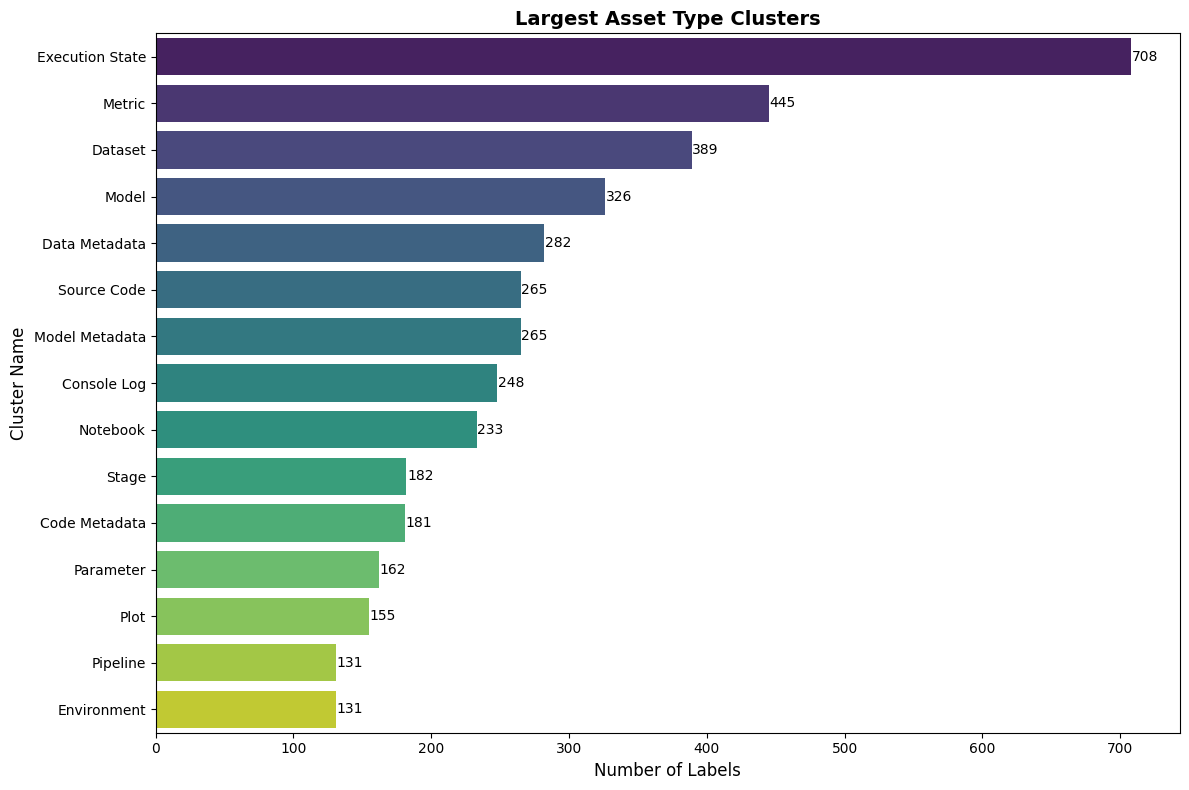

In [29]:
import pandas as pd
import numpy as np
import json
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

class HybridAssetClustering:
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        """
        Initialize the hybrid clustering system.
        
        Args:
            model_name: Sentence transformer model to use for embeddings
        """
        self.model = SentenceTransformer(model_name)
        self.seed_examples = {
            'Dataset': ['training data', 'test set', 'validation data', 'csv file', 'dataframe', 
                       'input data', 'raw data', 'preprocessed data', 'labeled data'],
            'Model': ['neural network', 'classifier', 'regressor', 'transformer', 'cnn', 
                     'lstm', 'random forest', 'svm', 'decision tree', 'ensemble'],
            'Parameter': ['learning rate', 'batch size', 'epochs', 'weights', 'bias', 
                         'dropout rate', 'regularization', 'optimizer', 'momentum'],
            'Source code': ['python script', 'training script', 'preprocessing code', 'main py', 
                           'utils', 'config file', 'requirements txt'],
            'Notebook': ['jupyter notebook', 'ipynb', 'analysis notebook', 'exploration notebook',
                        'demo notebook', 'tutorial notebook'],
            'Experiment': ['experiment run', 'trial', 'test run', 'experiment config', 
                          'hyperparameter search', 'ablation study'],
            'Data metadata': ['data schema', 'column info', 'data statistics', 'data quality',
                             'feature info', 'label distribution'],
            'Code metadata': ['code version', 'commit hash', 'branch name', 'code dependencies',
                             'function signature', 'class definition'],
            'Model metadata': ['model architecture', 'model size', 'model version', 'checkpoint',
                              'model config', 'layer info'],
            'Environment': ['python version', 'cuda version', 'operating system', 'dependencies',
                           'virtual environment', 'conda env'],
            'Container': ['docker image', 'dockerfile', 'container config', 'docker compose',
                         'kubernetes pod', 'container registry'],
            'Library': ['tensorflow', 'pytorch', 'scikit learn', 'pandas', 'numpy',
                       'matplotlib', 'seaborn', 'pip package'],
            'Stage': ['training stage', 'validation stage', 'testing stage', 'preprocessing stage',
                     'feature engineering', 'model evaluation'],
            'Pipeline': ['ml pipeline', 'data pipeline', 'training pipeline', 'inference pipeline',
                        'etl pipeline', 'workflow'],
            'Hardware consumption': ['gpu usage', 'cpu usage', 'memory usage', 'disk usage',
                                   'network io', 'power consumption'],
            'Execution state': ['running', 'completed', 'failed', 'pending', 'queued', 'cancelled'],
            'Event': ['training started', 'epoch completed', 'validation finished', 'error occurred',
                     'checkpoint saved', 'experiment ended'],
            'Console log': ['stdout', 'stderr', 'log message', 'debug info', 'warning message',
                           'error message'],
            'Metric': ['accuracy', 'precision', 'recall', 'f1 score', 'loss', 'auc', 'rmse',
                      'mae', 'mse', 'confusion matrix'],
            'Plot': ['training curve', 'loss plot', 'accuracy plot', 'confusion matrix plot',
                    'histogram', 'scatter plot', 'visualization'],
        }
        
        self.labels = None
        self.embeddings = None
        self.seed_centroids = None
        self.clusters = None
        self.cluster_assignments = None
        
    def load_data(self, file_path, label_column='label'):
        """
        Load labels from JSONL file.
        
        Args:
            file_path: Path to JSONL file
            label_column: Column name containing the labels
        """
        self.labels = []
        with open(file_path, 'r') as f:
            for line in f:
                data = json.loads(line.strip())
                if label_column in data:
                    self.labels.append(data[label_column])
        
        print(f"Loaded {len(self.labels)} labels from {file_path}")
        return self.labels
    
    def generate_embeddings(self):
        """Generate embeddings for all labels and seed examples."""
        print("Generating embeddings...")
        
        # Combine all labels and seed examples
        all_texts = self.labels.copy()
        seed_texts = []
        for asset_type, examples in self.seed_examples.items():
            seed_texts.extend(examples)
        
        all_texts.extend(seed_texts)
        
        # Generate embeddings
        embeddings = self.model.encode(all_texts, show_progress_bar=True)
        
        # Split embeddings
        self.embeddings = embeddings[:len(self.labels)]
        seed_embeddings = embeddings[len(self.labels):]
        
        # Calculate seed centroids
        self.seed_centroids = {}
        start_idx = 0
        for asset_type, examples in self.seed_examples.items():
            end_idx = start_idx + len(examples)
            centroid = np.mean(seed_embeddings[start_idx:end_idx], axis=0)
            self.seed_centroids[asset_type] = centroid
            start_idx = end_idx
        
        print(f"Generated embeddings: {self.embeddings.shape}")
        return self.embeddings
    
    def phase1_seed_assignment(self, confidence_threshold=0.3):
        """Phase 1: Assign labels to seed centroids with confidence filtering."""
        print("\nPhase 1: Initial seed-based assignment...")
        
        assignments = {}
        confidences = {}
        unassigned = []
        
        for i, label in enumerate(self.labels):
            label_embedding = self.embeddings[i].reshape(1, -1)
            
            # Calculate similarities to all seed centroids
            similarities = {}
            for asset_type, centroid in self.seed_centroids.items():
                centroid_reshaped = centroid.reshape(1, -1)
                sim = cosine_similarity(label_embedding, centroid_reshaped)[0, 0]
                similarities[asset_type] = sim
            
            # Find best match
            best_type = max(similarities, key=similarities.get)
            best_sim = similarities[best_type]
            
            if best_sim >= confidence_threshold:
                assignments[label] = best_type
                confidences[label] = best_sim
            else:
                unassigned.append(label)
        
        print(f"Assigned {len(assignments)} labels to seed clusters")
        print(f"Unassigned (low confidence): {len(unassigned)} labels")
        
        return assignments, confidences, unassigned
    
    def phase2_discover_new_clusters(self, unassigned_labels, min_cluster_size=3):
        """Phase 2: Discover new clusters from unassigned labels."""
        if not unassigned_labels:
            return {}
        
        print(f"\nPhase 2: Discovering new clusters from {len(unassigned_labels)} unassigned labels...")
        
        # Get embeddings for unassigned labels
        unassigned_indices = [self.labels.index(label) for label in unassigned_labels]
        unassigned_embeddings = self.embeddings[unassigned_indices]
        
        # Try DBSCAN clustering
        dbscan = DBSCAN(eps=0.3, min_samples=min_cluster_size, metric='cosine')
        cluster_labels = dbscan.fit_predict(unassigned_embeddings)
        
        # Organize discovered clusters
        discovered_clusters = defaultdict(set)
        for i, cluster_id in enumerate(cluster_labels):
            if cluster_id != -1:  # Not noise
                discovered_clusters[f"new_cluster_{cluster_id}"].add(unassigned_labels[i])
        
        # Filter out small clusters
        discovered_clusters = {k: v for k, v in discovered_clusters.items() 
                             if len(v) >= min_cluster_size}
        
        print(f"Discovered {len(discovered_clusters)} new clusters:")
        for cluster_name, members in discovered_clusters.items():
            print(f"{cluster_name}: {members}")
        
        return discovered_clusters
    
    def phase3_refinement(self, initial_assignments, discovered_clusters, max_iterations=3):
        """Phase 3: Iterative refinement of clusters."""
        print(f"\nPhase 3: Refining clusters...")
        
        # Combine initial assignments and discovered clusters
        all_clusters = {}
        
        # Add initial assignments
        for label, asset_type in initial_assignments.items():
            if asset_type not in all_clusters:
                all_clusters[asset_type] = []
            all_clusters[asset_type].append(label)
        
        # Add discovered clusters
        all_clusters.update(discovered_clusters)
        
        # Iterative refinement
        for iteration in range(max_iterations):
            print(f"  Refinement iteration {iteration + 1}")
            
            # Recalculate centroids
            new_centroids = {}
            for cluster_name, members in all_clusters.items():
                if members:
                    member_indices = [self.labels.index(label) for label in members 
                                    if label in self.labels]
                    if member_indices:
                        cluster_embeddings = self.embeddings[member_indices]
                        new_centroids[cluster_name] = np.mean(cluster_embeddings, axis=0)
            
            # Reassign labels based on new centroids
            reassignments = 0
            new_clusters = defaultdict(list)
            
            for label in self.labels:
                label_embedding = self.embeddings[self.labels.index(label)].reshape(1, -1)
                
                # Find best cluster
                best_cluster = None
                best_similarity = -1
                
                for cluster_name, centroid in new_centroids.items():
                    centroid_reshaped = centroid.reshape(1, -1)
                    sim = cosine_similarity(label_embedding, centroid_reshaped)[0, 0]
                    
                    if sim > best_similarity:
                        best_similarity = sim
                        best_cluster = cluster_name
                
                if best_cluster and best_similarity > 0.2:  # Minimum similarity threshold
                    new_clusters[best_cluster].append(label)
                    
                    # Check if this is a reassignment
                    old_cluster = None
                    for cluster_name, members in all_clusters.items():
                        if label in members:
                            old_cluster = cluster_name
                            break
                    
                    if old_cluster and old_cluster != best_cluster:
                        reassignments += 1
            
            all_clusters = dict(new_clusters)
            print(f"    Reassignments: {reassignments}")
            
            if reassignments < 10:  # Convergence threshold
                break
        
        self.clusters = all_clusters
        return all_clusters
    
    def analyze_clusters(self):
        """Analyze and report cluster quality."""
        if not self.clusters:
            print("No clusters to analyze. Run clustering first.")
            return
        
        print("\n" + "="*50)
        print("CLUSTER ANALYSIS RESULTS")
        print("="*50)
        
        total_labels = sum(len(members) for members in self.clusters.values())
        print(f"Total labels clustered: {total_labels}/{len(self.labels)}")
        print(f"Number of clusters: {len(self.clusters)}")
        
        # Cluster size distribution
        sizes = [len(members) for members in self.clusters.values()]
        print(f"\nCluster size statistics:")
        print(f"  Mean: {np.mean(sizes):.1f}")
        print(f"  Median: {np.median(sizes):.1f}")
        print(f"  Min: {min(sizes)}, Max: {max(sizes)}")
        
        # Detailed cluster information
        print(f"\nDetailed cluster breakdown:")
        for cluster_name, members in sorted(self.clusters.items(), 
                                          key=lambda x: len(x[1]), reverse=True):
            print(f"\n{cluster_name} ({len(members)} labels):")
            
            # Show sample members
            sample_size = min(10, len(members))
            sample = sorted(members)[:sample_size]
            print(f"  Sample: {', '.join(sample)}")
            
            if len(members) > sample_size:
                print(f"  ... and {len(members) - sample_size} more")
        
        return self.clusters
    
    def save_results(self, output_path):
        """Save clustering results to JSON file."""
        if not self.clusters:
            print("No clusters to save. Run clustering first.")
            return
        
        results = {
            'metadata': {
                'total_labels': len(self.labels),
                'total_clusters': len(self.clusters),
                'labels_clustered': sum(len(members) for members in self.clusters.values())
            },
            'clusters': self.clusters
        }
        
        with open(output_path, 'w') as f:
            json.dump(results, f, indent=2)
        
        print(f"\nResults saved to {output_path}")
    
    def visualize_clusters(self, max_labels_per_cluster=20):
        """Create visualizations of the clustering results."""
        if not self.clusters:
            print("No clusters to visualize. Run clustering first.")
            return
        
        # Prepare data for visualization
        cluster_names = list(self.clusters.keys())
        cluster_sizes = [len(self.clusters[name]) for name in cluster_names]
        
        # Sort by size and take top 15
        sorted_clusters = sorted(zip(cluster_names, cluster_sizes), 
                               key=lambda x: x[1], reverse=True)[:15]
        
        names, sizes = zip(*sorted_clusters)
        
        # Create the plot using seaborn
        plt.figure(figsize=(12, 8))
        ax = sns.barplot(x=list(sizes), y=[name.replace('_', ' ').title() for name in names], 
                         palette='viridis')
        
        # Customize the plot
        plt.xlabel('Number of Labels', fontsize=12)
        plt.ylabel('Cluster Name', fontsize=12)
        plt.title('Largest Asset Type Clusters', fontsize=14, fontweight='bold')
        
        # Add value labels on bars
        for i, v in enumerate(sizes):
            ax.text(v + 0.5, i, str(v), va='center', fontsize=10)
        
        plt.tight_layout()
        plt.show()
    
    def run_full_pipeline(self, file_path, label_column='label', 
                         confidence_threshold=0.3, output_path='clustering_results.json'):
        """Run the complete hybrid clustering pipeline."""
        print("Starting Hybrid Asset Type Clustering Pipeline")
        print("="*50)
        
        # Load data
        self.load_data(file_path, label_column)
        
        # Generate embeddings
        self.generate_embeddings()
        
        # Phase 1: Seed-based assignment
        assignments, confidences, unassigned = self.phase1_seed_assignment(confidence_threshold)
        
        # Phase 2: Discover new clusters
        discovered = self.phase2_discover_new_clusters(unassigned)
        
        # Phase 3: Refinement
        final_clusters = self.phase3_refinement(assignments, discovered)
        
        # Analysis and output
        self.analyze_clusters()
        self.save_results(output_path)
        self.visualize_clusters()
        
        return final_clusters

# Run the full clustering pipeline
clusterer = HybridAssetClustering()
results = clusterer.run_full_pipeline(
    file_path='data/unused_python_functions_analyzed.jsonl',
    label_column='noun',  # or whatever your label column is called
    confidence_threshold=0.3,
    output_path='data/unused_python_functions_assets.json'
)

In [10]:
import os
import re
import pandas as pd
from pathlib import Path

def retrieve_script(loc):
    local_path = loc.split(":")[0]
    content = open(local_path, "r", encoding="utf-8").read()
    return content

def preprocess_path(path):
    path_parts = path.split(os.sep)
    org_name, repo_name = path_parts[2].split("__")[0], path_parts[2].split("__")[1]
    file_name, line_number = path_parts[-1].split(':')[0], path_parts[-1].split(':')[1]
    file_path = os.path.join(*path_parts[3:-1]).replace(os.sep, "/")
    file_path_url = f"https://github.com/{org_name}/{repo_name}/blob/{repo_commit_info[repo_name]}/{file_path}/{file_name}#L{line_number}"
    return file_path_url

def python_grep(pattern, directory, include_pattern="*.py", exclude_dirs=None):
    """
    Python replacement for grep -rn -E pattern directory --include=*.py --exclude-dir=...
    
    Args:
        pattern (str): Regular expression pattern to search for
        directory (Path): Directory to search in
        include_pattern (str): File pattern to include (default: "*.py")
        exclude_dirs (list): List of directory names to exclude
    
    Returns:
        list: List of strings in format "filepath:line_number:line_content"
    """
    if exclude_dirs is None:
        exclude_dirs = []
    
    results = []
    
    # Compile the regex pattern
    try:
        regex = re.compile(pattern, re.MULTILINE)
    except re.error as e:
        print(f"Invalid regex pattern: {e}")
        return results
    
    # Convert include_pattern to regex if it contains wildcards
    if "*" in include_pattern:
        include_regex = re.compile(include_pattern.replace("*", ".*"))
    else:
        include_regex = re.compile(re.escape(include_pattern))
    
    # Walk through directory recursively
    for root, dirs, files in os.walk(directory):
        # Remove excluded directories from dirs list to prevent walking into them
        dirs[:] = [d for d in dirs if d not in exclude_dirs]
        
        for file in files:
            # Check if file matches include pattern
            if not include_regex.match(file):
                continue
                
            file_path = os.path.join(root, file)
            
            try:
                with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                    for line_num, line in enumerate(f, 1):
                        if regex.search(line):
                            # Format similar to grep output: filepath:line_number:line_content
                            result_line = f"{file_path}:{line_num}:{line.rstrip()}"
                            results.append(result_line)
            except (IOError, OSError) as e:
                print(f"Error reading file {file_path}: {e}")
                continue
    
    return results

# Only exclude directories that contain Python files we DON'T want to search
exclude_dirs = [
    '.git',           # May contain .py files in hooks/scripts
    '__pycache__',    # Contains .pyc files (not .py, but just in case)
    'venv', '.venv',  # Virtual env contains installed packages (.py files)
    'site-packages', # Installed packages
    'node_modules'    # May contain .py files in some JS projects
]

df_harness = pd.read_csv("data/evaluation_harness_metadata.csv", encoding="utf-8")
df_harness['repo'] = df_harness['repo'].apply(lambda x: x.split("/")[4])
repo_harness_mapping = dict(zip(df_harness["repo"], df_harness["harness"]))

def loc_harness_mapping(repo):
    if '/' in repo:
        repo = repo.split("/")[4]
    if repo in repo_harness_mapping:
        return repo_harness_mapping[repo]
    elif "evalai-cli" == repo:
        return "EvalAI"

df = []
path_repo = Path("data/repos")

for dependency, pattern in usage_pattern_mapping.items():
    usage_pattern = f"^\\s*import\\s+{pattern}|^\\s*from\\s+{pattern}(\\.[a-zA-Z_][a-zA-Z0-9_]*)*\\s+import"
    
    for repo_path in path_repo.iterdir():
        dependent = repo_path.name.split("__")[-1]
        if dependency == dependent:
            continue
        
        if ".json" in str(repo_path):
            continue
        
        # Use Python grep replacement instead of subprocess
        grep_results = python_grep(
            pattern=usage_pattern,
            directory=repo_path,
            include_pattern="*.py",
            exclude_dirs=exclude_dirs
        )
        
        for line in grep_results:
            loc = preprocess_path(line)
            usecase_dict = {
                "dependent": loc_harness_mapping(dependent),
                "dependency": loc_harness_mapping(dependency),
                "line of code": loc,
                "content": retrieve_script(line),
            }
            df.append(usecase_dict)

df = pd.DataFrame(df)
df.to_json("data/inter_harness_dependencies.jsonl", orient="records", lines=True)